# Task set 2 — guided design against an ordinary target

Figures for the **second** design task set in this folder ([`in-silico-test/`](.)): the one
[`2_design_task_specification/curate_pairs_task2.py`](2_design_task_specification/curate_pairs_task2.py) builds by pairing each
scaffold with a **randomly drawn** qualifying target instead of its most spectrally distant one. This
is the folder's design write-up. It began as the task-2 counterpart of Sections 8-9 of
[`visualization.ipynb`](visualization.ipynb) — the same two questions, the same idiom, the same
statistics, a different task set — and those sections have since been archived with task set 1
itself ([`archive/visualization_task1_design.ipynb`](archive/visualization_task1_design.ipynb)),
so the two are still read side by side, one folder apart. Figure 1 is drawn exactly as
Section 8's is; Figure 4 asks Section 9's question of the three deployable methods rather than
plotting the peaks themselves, for the reason given in Section 2. Figure 2 has no counterpart there:
it is Figure 1's success counts re-asked at every threshold rather than at zero.

Sections 1-7 of `visualization.ipynb` (the landscape, the nested split, both architecture sweeps and
both models' held-out predictions) are **task-independent**: task set 2 uses the same 758 curated
proteins, the same nested split, and the same two deployed models. They are not repeated here.

| | task set 1, archived (`pairs/`) | task set 2 (`pairs_task2/`) |
|---|---|---|
| target rule | most spectrally distant qualifying target | uniform draw from the same qualifying set |
| eligibility | identity 50-98%, ≥40 nm ex/em distance, ±30 length, oracle-train targets, validated scaffolds | **identical** |
| median scaffold→target distance | 190 nm | **79 nm** |
| distinct targets | 17 over 108 tasks | **60 over 72 tasks** |
| cohorts | S-train / S-val / S-test (36 each) | S-pool (36) / S-test (36) |

The cohorts differ only in when the merge happens. The deployed surrogate was refit on train ∪ val,
so an S-val scaffold sits inside its training data exactly as an S-train scaffold does; task set 1
kept three manifests to balance a per-role distance spread and merged them at analysis time, task set
2 merges up front into **S-pool** (in the training pool) against **S-test** (never trained on).

**One arm differs from the archived task-1 figures.** There the guided arm was the family-MSA
proposal ([`archive/3.1_design_run_MSA`](archive/3.1_design_run_MSA)); here it is the ESM-2 masked-LM proposal
([`3.1_design_run_ESM2`](3.1_design_run_ESM2)), because only the ESM-2 arm was re-run on task set 2.
On task set 1 the two proposals are statistically indistinguishable (1.3 nm apart on the mean over
trials, *p* = 0.60, on the same 72 tasks — see the README's three-arm table), so a comparison across
the two notebooks reads as a comparison of **task sets**, not of proposals. The unguided control is
the same construction in both: the guided arm with λ_ex = λ_em = 0.

1. **Guided design vs. an unguided control** — the distribution of distances to the target at the
   final design cycle, against a trial-matched arm run with the surrogate taken out of the loop
   entirely, and against that same arm filtered by the surrogate afterwards; then how many pairs
   each method improves as the improvement demanded of it rises.
2. **How far each method landed from its target** — the absolute offset for the surrogate's top pick,
   its top-3 mean and the unguided control, one ranked block per method, which is where the value of
   guidance and the point at which it runs out both become visible.
3. **Why the unguided control improves at all** — it collapses onto the middle of the FP
   distribution, so its score is close to that of a predictor which ignores the task entirely. This
   one has no counterpart in `visualization.ipynb`; it is what makes the other two readable.

Figures follow the **2026 Arcadia style guide**, as in `visualization.ipynb`.

> Run from `in-silico-test/`. Prerequisites, in order: `2_design_task_specification/curate_pairs_task2.py`,
> `2_design_task_specification/build_windows.py --cohorts knownstruct_Spool
> knownstruct_Stest`, `3.1_design_run_ESM2/run_task2_esm2.py`, `3.2_design_run_gibbs/run_task2_gibbs.py`,
> and `score_traj_surrogate.py --arm esm2_t2_rand3` / `--arm gibbs_t2_r12` for the surrogate's own
> view of each round. Fonts are the one-off `python fetch_arcadia_fonts.py` in `dataset_pipeline/`.

In [21]:
# The inline backend crops to "tight" by default, which silently rescales every figure and
# throws away the guide's panel dimensions. Turn it off so a 1000px panel really is 1000px.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import arcadia_pycolor as apc

# Fonts are produced under dataset_pipeline/ and are shared and split-independent -- read from
# there unchanged, exactly as visualization.ipynb does.
DP = "../dataset_pipeline"
FONTS = f"{DP}/fonts"
apc.mpl.setup(font_dirpath=FONTS if os.path.isdir(FONTS) else None)
if not os.path.isdir(FONTS):
    print("NOTE: run `python fetch_arcadia_fonts.py` in dataset_pipeline/ for the Atkinson faces")

# apc sets figure.dpi to 72 so that one point equals one style-guide pixel. Keep that
# correspondence for layout, but render at 2x so the inline PNGs are not soft on screen.
plt.rcParams["figure.dpi"] = 144
RNG_SEED = 0

# experiment root + vendored lib on the import path (the pipeline scripts live in stage dirs)
for _p in ("", "lib"):
    _a = os.path.abspath(_p)
    if _a not in sys.path:
        sys.path.insert(0, _a)

import design_common as dc            # every path in this experiment, task set 2 included
import score_traj_surrogate as sts    # the surrogate's per-round view, cached next to each arm

FIGDIR = "figures"                    # this folder's own figures, as in visualization.ipynb
os.makedirs(FIGDIR, exist_ok=True)
print("environment ready")

environment ready


### Style-guide helpers

The subset of `visualization.ipynb`'s helpers these two figures use, unchanged, so a panel here and a
panel there are drawn to the same rules.

In [22]:
PX = 1 / 72                       # one style-guide pixel, expressed in inches
FULL_WIDE, FLOAT, HALF_SQUARE = 1000, 650, 490

# Text roles, straight from the guide's "Text styles" page
PANEL_LETTER = dict(fontsize=38, fontweight="regular", color=str(apc.chateau))
ANNOTATION = dict(fontsize=15, fontweight="ultralight", color=str(apc.charcoal))
NUMBER_NOTE = dict(fontfamily="Atkinson Hyperlegible Mono", fontsize=14.5,
                   color=str(apc.charcoal))
# The same role one size down, for notes that sit inside a crowded panel rather than beside it.
ANNOT = dict(fontsize=11, fontweight="ultralight", color=str(apc.charcoal))

HIGHLIGHT, CONTRAST = str(apc.aegean), str(apc.amber)
# A third data colour, for the one series that is neither of the two conditions: the unguided
# control arm, which has to read as the same series on both sides of a figure.
CONTROL = str(apc.aster)
NEUTRAL, NEUTRAL_SOFT = str(apc.chateau), str(apc.taupe)


def panel_letter(ax, letter, dx=-46, dy=12):
    """Place a panel letter at the top-left corner of a 2-D axes, in the guide's style."""
    ax.annotate(letter, xy=(0, 1), xycoords="axes fraction",
                xytext=(dx, dy), textcoords="offset points",
                ha="left", va="bottom", annotation_clip=False, **PANEL_LETTER)


def key(ax, handles, **kw):
    """A frameless key. style_plot must already have run on the axes: calling it afterwards
    re-triggers apc's style_legend, which draws a stray rule above the entries at 144 dpi."""
    leg = ax.legend(handles=handles, frameon=False, fontsize=10.5, handletextpad=0.4,
                    labelspacing=0.35, borderaxespad=0.2, **kw)
    apc.mpl.capitalize_legend_text(leg)
    return leg


## 1. Guided design, cycle by cycle — against an unguided control

The question Section 8 of `visualization.ipynb` asks of task set 1, asked again of an ordinary
target: **does the guided search move a scaffold toward a target it was pointed at, and how much of
that movement is the guidance?** Two arms, on the same tasks:

- **Guided** ([`3.1_design_run_ESM2/run_task2_esm2.py`](3.1_design_run_ESM2/run_task2_esm2.py)): at
  each editable position the candidate substitutions are ESM-2's top 10 under the window's structural
  constraints, ranked by `z(logp_esm) − z(|Δex|) − z(|Δem|)` where the two error terms are the
  **surrogate's** distance to the target. 3 trials × 2 cycles per task, of which the figure draws
  the **final** cycle; the intermediate one is measured and printed beside it.
- **Unguided** ([`3.2_design_run_gibbs/run_task2_gibbs.py`](3.2_design_run_gibbs/run_task2_gibbs.py)):
  the same windows and the same proposal machinery with λ_ex = λ_em = 0 — Gibbs sampling from the
  ESM-2 masked LM with the surrogate removed from the loop. 12 trials × 2 cycles, of which the
  **first 3 are used** so both arms get the same number of draws per task; more trials shrink the
  error on a task's mean and stretch both tails for free, which would make the control differ for a
  reason that has nothing to do with guidance. The 12-trial means are printed alongside.
- **Unguided, surrogate-selected** — the same 12 unguided trials with the surrogate put back, but
  only *after* the search: rank a task's 12 final designs by the surrogate's own distance to the
  target and average the **top 3**. The guidance and the selection use the same model, so the pair
  of unguided groups separates what the surrogate is worth *inside* the loop from what it is worth
  as a filter over finished designs. It is the one group that is deliberately **not**
  budget-matched — picking 3 of 12 costs 12 draws — so it is read against the 12-trial control mean
  in the printout, not against the 3-trial group beside it.

A cycle is one pass over the scaffold's editable window: chromophore positions 1-2, then the 5 Å
pocket. What is plotted is neither arm's own opinion of itself but the **oracle's** distance to the
target, on the ProstT5 side of the pipeline and never consulted by either search: the mean of the two
absolute peak offsets, 0.5(|Δex| + |Δem|), in the same nm as the MAEs in `visualization.ipynb`.
Round 0 is the unedited scaffold, so it is the distance each task started at and the bar everything
else has to beat.

Unlike Section 8, **no task has to be dropped**: both arms ran the same 36 + 36 pairs, since task set
2's cohorts were merged when they were selected rather than when they are reported.

In [23]:
import glob
from itertools import combinations

from scipy.stats import ttest_rel, wilcoxon

# Two arms of the task-2 design stage, on the identical 72 tasks.
#
#   GUIDED     3.1_design_run_ESM2 -- ESM-2 masked-LM proposals ranked with the SURROGATE's distance
#              to the target in the score. 72 tasks x 3 trials x 2 cycles.
#   UNGUIDED   3.2_design_run_gibbs -- the same windows, the same proposal machinery,
#              lam_ex = lam_em = 0: Gibbs sampling from the ESM-2 masked LM with the surrogate taken
#              out of the loop entirely. 72 tasks x 12 trials x 2 cycles.
#
# The conditions are the two cohorts curate_pairs_task2.py writes: S-pool, whose scaffolds are inside
# the deployed surrogate's train+val refit pool, and S-test, whose scaffolds it never saw.
CONDS = ["S-pool", "S-test"]
COHORT_LABEL = {"knownstruct_Spool": "S-pool", "knownstruct_Stest": "S-test"}
DTYPE = {"scaffold_name": str, "target_name": str}   # one dataset entry is literally named "11"


def load_arm(pipe, arm, cohorts=None):
    """Every trajectory of one arm, with the surrogate's own view of each round merged in.

    `peak_err` is the ORACLE's distance to the target as the design loop defines it -- the mean of
    the two absolute peak offsets, 0.5(|dex| + |dem|). `surr_err` is that same distance under the
    SURROGATE, which the design run never writes out (it logs only the accepted sequence),
    recomputed and cached by score_traj_surrogate.py.
    """
    frames = []
    for coh, label in (cohorts or COHORT_LABEL).items():
        for fn in sorted(glob.glob(os.path.join(str(pipe), coh, "design_*.csv"))):
            d = pd.read_csv(fn, dtype=DTYPE)
            d["cond"] = label
            frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    return df.merge(sts.compute(arm, verbose=False), on=["example", "trial", "round"], how="left")


guided = load_arm(dc.PIPE_OUT_ESM2_T2_R3, "esm2_t2_rand3")
unguided = load_arm(dc.PIPE_OUT_GIBBS_T2_R12, "gibbs_t2_r12")
# Both arms ran the same manifests, so this is an equality rather than an intersection -- assert it
# instead of silently taking whichever tasks happen to overlap.
assert set(guided.example) == set(unguided.example), "the two arms must cover the same tasks"
LAST = int(guided["round"].max())
assert int(unguided["round"].max()) == LAST, "the two arms must be compared at the same cycle"

TOP_K = 3


def top_k_by_surrogate(df, k=TOP_K):
    """A task's k best candidate designs as the SURROGATE ranks them -- a rule the search can apply,
    unlike ranking by oracle error, which would consult the held-out judge. The pool is every design
    the task produced, both cycles of every trial (6 guided, 24 unguided), since a candidate is a
    candidate whichever cycle it came out of.
    """
    return (df[df["round"] >= 1].sort_values("surr_err")
            .groupby("example", sort=False).head(k))


top3 = top_k_by_surrogate(guided)                 # Figure 4's selection series
FINAL_GUIDED = guided[guided["round"] == LAST]
FINAL_UNGUIDED = unguided[unguided["round"] == LAST]

# The control ran 12 trials to the guided arm's 3. A 12-trial group is not a like-for-like control:
# more draws shrink the error on a task's mean and stretch both tails for free. Figure 1 therefore
# uses the control's FIRST THREE trials, matching the guided arm's budget exactly; the 12-trial
# numbers are printed below for reference.
UNGUIDED_TRIALS = 3
FINAL_UNGUIDED_3 = FINAL_UNGUIDED[FINAL_UNGUIDED.trial < UNGUIDED_TRIALS]

# The fifth group, and the only one not budget-matched: the SURROGATE's top 3 of the control's 12
# final designs, averaged. It is what a campaign can do with an unguided sampler and the surrogate
# used purely as a FILTER over finished designs, as against the guided arm, which spends the same
# model inside the loop. The ranking rule is Figure 4's, applied to the control's 12-design pool
# rather than the guided arm's; ranking by oracle error instead would consult the held-out judge and
# is not a rule a campaign could follow.
TOP3_UNGUIDED = top_k_by_surrogate(FINAL_UNGUIDED)

# THE DESIGN PAIR IS THE UNIT, NOT THE DESIGN. A task's trials are repeated draws on the same
# scaffold->target problem, so each group is summarised per task first -- the mean over its trials,
# with the SD across them carried alongside as that task's own uncertainty. Everything downstream
# (violins, dots, error bars, tests) is on these 36-per-condition numbers, not on 216 designs.
# Round 0 is the unedited scaffold, the same sequence in every trial, so its SD is fp16 batching
# noise (<= 0.2 nm) rather than a spread; in the selection group the SD is the spread over the three
# designs that were KEPT, not over repeated draws, since selection is part of what that method is.
#
# The guided arm appears at its FINAL cycle only. Every group in the figure then differs in kind --
# no edit, guided, unguided, unguided-then-filtered -- where cycle 1 differs from cycle 2 only in how
# far the same search was run, a question the aside printed below settles on its own. Dropping it
# takes the pairwise family from ten tests to six and empties the middle of the bracket stack.
GROUPS = ["Scaffold", "Guided", "Gibbs\nsampling", "Gibbs top 3\n(out of 12)"]
SOURCE = {GROUPS[0]: guided[guided["round"] == 0],
          GROUPS[1]: FINAL_GUIDED,
          GROUPS[2]: FINAL_UNGUIDED_3,
          GROUPS[3]: TOP3_UNGUIDED}
CYCLE1 = {c: guided[(guided["round"] == 1) & (guided.cond == c)].groupby("example").peak_err.mean()
          for c in CONDS}

PER_TASK, PER_TASK_SD = {}, {}
for c in CONDS:
    PER_TASK[c] = pd.DataFrame({g: df[df.cond == c].groupby("example").peak_err.mean()
                                for g, df in SOURCE.items()})
    PER_TASK_SD[c] = pd.DataFrame({g: df[df.cond == c].groupby("example").peak_err.std(ddof=1)
                                   for g, df in SOURCE.items()})
POINTS = {(c, g): PER_TASK[c][g].to_numpy() for c in CONDS for g in GROUPS}
POINT_SD = {(c, g): PER_TASK_SD[c][g].to_numpy() for c in CONDS for g in GROUPS}

# Paired across the 36 tasks of a condition, because every task appears in every group -- including
# against the scaffold, which is the comparison that asks whether a group moved at all. Wilcoxon
# signed-rank is printed beside the t-test as a distribution-free check and Holm across a condition's
# six tests guards the multiplicity; the figure annotates raw p and only where it clears ALPHA, so an
# unmarked pair is one the test could not separate.
TESTS = list(combinations(GROUPS, 2))
ALPHA = 0.05
PAIRED = {}
for c in CONDS:
    t = PER_TASK[c]
    for a, b in TESTS:
        d = t[a] - t[b]
        r = ttest_rel(t[a], t[b])
        PAIRED[(c, a, b)] = dict(n=len(t), diff=d.mean(), sd=d.std(ddof=1), t=r.statistic,
                                 df=len(t) - 1, p=r.pvalue, dz=d.mean() / d.std(ddof=1),
                                 p_wilcoxon=wilcoxon(t[a], t[b]).pvalue)
    # Holm: sort this condition's p values, scale each by (m - rank), keep the sequence monotone
    run = 0.0
    for rank, (p, a, b) in enumerate(sorted((PAIRED[(c, a, b)]["p"], a, b) for a, b in TESTS)):
        run = max(run, min(1.0, (len(TESTS) - rank) * p))
        PAIRED[(c, a, b)]["p_holm"] = run


def _flat(g):
    return g.replace("\n", " ")


print(f"{len(guided.example.unique())} tasks in both arms | guided {guided.trial.nunique()} trials, "
      f"unguided {unguided.trial.nunique()} ({UNGUIDED_TRIALS} used), {LAST} cycles each")
for c in CONDS:
    t, sd = PER_TASK[c], PER_TASK_SD[c]
    print(f"  {c} ({len(t)} tasks): " + " | ".join(f"{_flat(g)} {t[g].mean():.1f} nm" for g in GROUPS))
    print("    " + " | ".join(f"{_flat(g)} median {t[g].median():.1f}, quartiles "
                              f"{t[g].quantile(.25):.1f}-{t[g].quantile(.75):.1f}, mean trial SD "
                              f"{sd[g].mean():.1f}" for g in GROUPS[1:]))
    print("    tasks whose mean design beats the scaffold: "
          + ", ".join(f"{_flat(g)} {int((t[g] < t[GROUPS[0]]).sum())}/{len(t)}" for g in GROUPS[1:])
          + " | guided closer than "
          + ", ".join(f"{_flat(g)} on {int((t[GROUPS[1]] < t[g]).sum())}/{len(t)}" for g in GROUPS[2:]))
    u12 = FINAL_UNGUIDED[FINAL_UNGUIDED.cond == c].groupby("example").peak_err.mean()
    print(f"    control on all 12 trials: {u12.mean():.1f} nm (the 3 used: {t[GROUPS[2]].mean():.1f}; "
          f"the surrogate's best 3 of the 12: {t[GROUPS[3]].mean():.1f})")
    # The cycle the figure leaves out, and the test that licenses leaving it out. Reported on its
    # own rather than inside the Holm family, which is over the four groups actually plotted.
    r1 = ttest_rel(CYCLE1[c], t[GROUPS[1]])
    print(f"    cycle 1, measured but not plotted: {CYCLE1[c].mean():.1f} nm -> cycle 2 "
          f"{t[GROUPS[1]].mean():.1f} ({CYCLE1[c].mean() - t[GROUPS[1]].mean():+.1f} nm, "
          f"t({len(t) - 1}) = {r1.statistic:+.2f}, p = {r1.pvalue:.2f})")

print(f"\npaired t-tests over per-pair means (n = {len(PER_TASK[CONDS[0]])} tasks per condition)")
for c in CONDS:
    print(f"  {c}")
    for a, b in TESTS:
        r = PAIRED[(c, a, b)]
        mark = "" if r["p"] < ALPHA else "   <- unmarked in the figure"
        print(f"    {_flat(a) + ' vs ' + _flat(b):30} {r['diff']:+7.1f} nm (SD {r['sd']:4.1f}) | "
              f"t({r['df']}) = {r['t']:+6.2f} | dz {r['dz']:+.2f} | p = {r['p']:.2g} "
              f"(Holm {r['p_holm']:.2g}, Wilcoxon {r['p_wilcoxon']:.2g}){mark}")

# Task set 1's counterpart numbers, for the cross-notebook read (README's three-arm table, same
# statistic: the per-task mean over trials at the final cycle, on the 72 tasks 3.2 and 3.3 share).
print("\nfor comparison, task set 1 (visualization.ipynb Section 8, ESM-2 guided vs Gibbs): "
      "scaffold 132.9 -> guided 91.4, unguided 105.8 nm")

72 tasks in both arms | guided 3 trials, unguided 12 (3 used), 2 cycles each
  S-pool (36 tasks): Scaffold 72.9 nm | Guided 38.4 nm | Gibbs sampling 47.7 nm | Gibbs top 3 (out of 12) 44.1 nm
    Guided median 26.7, quartiles 19.0-47.7, mean trial SD 12.0 | Gibbs sampling median 35.4, quartiles 23.4-65.8, mean trial SD 8.8 | Gibbs top 3 (out of 12) median 35.1, quartiles 15.2-71.2, mean trial SD 7.6
    tasks whose mean design beats the scaffold: Guided 35/36, Gibbs sampling 34/36, Gibbs top 3 (out of 12) 35/36 | guided closer than Gibbs sampling on 30/36, Gibbs top 3 (out of 12) on 22/36
    control on all 12 trials: 47.0 nm (the 3 used: 47.7; the surrogate's best 3 of the 12: 44.1)
    cycle 1, measured but not plotted: 39.7 nm -> cycle 2 38.4 (+1.2 nm, t(35) = +1.18, p = 0.25)
  S-test (36 tasks): Scaffold 67.4 nm | Guided 49.3 nm | Gibbs sampling 58.7 nm | Gibbs top 3 (out of 12) 58.3 nm
    Guided median 36.0, quartiles 25.6-61.5, mean trial SD 12.2 | Gibbs sampling median 48.5, qu

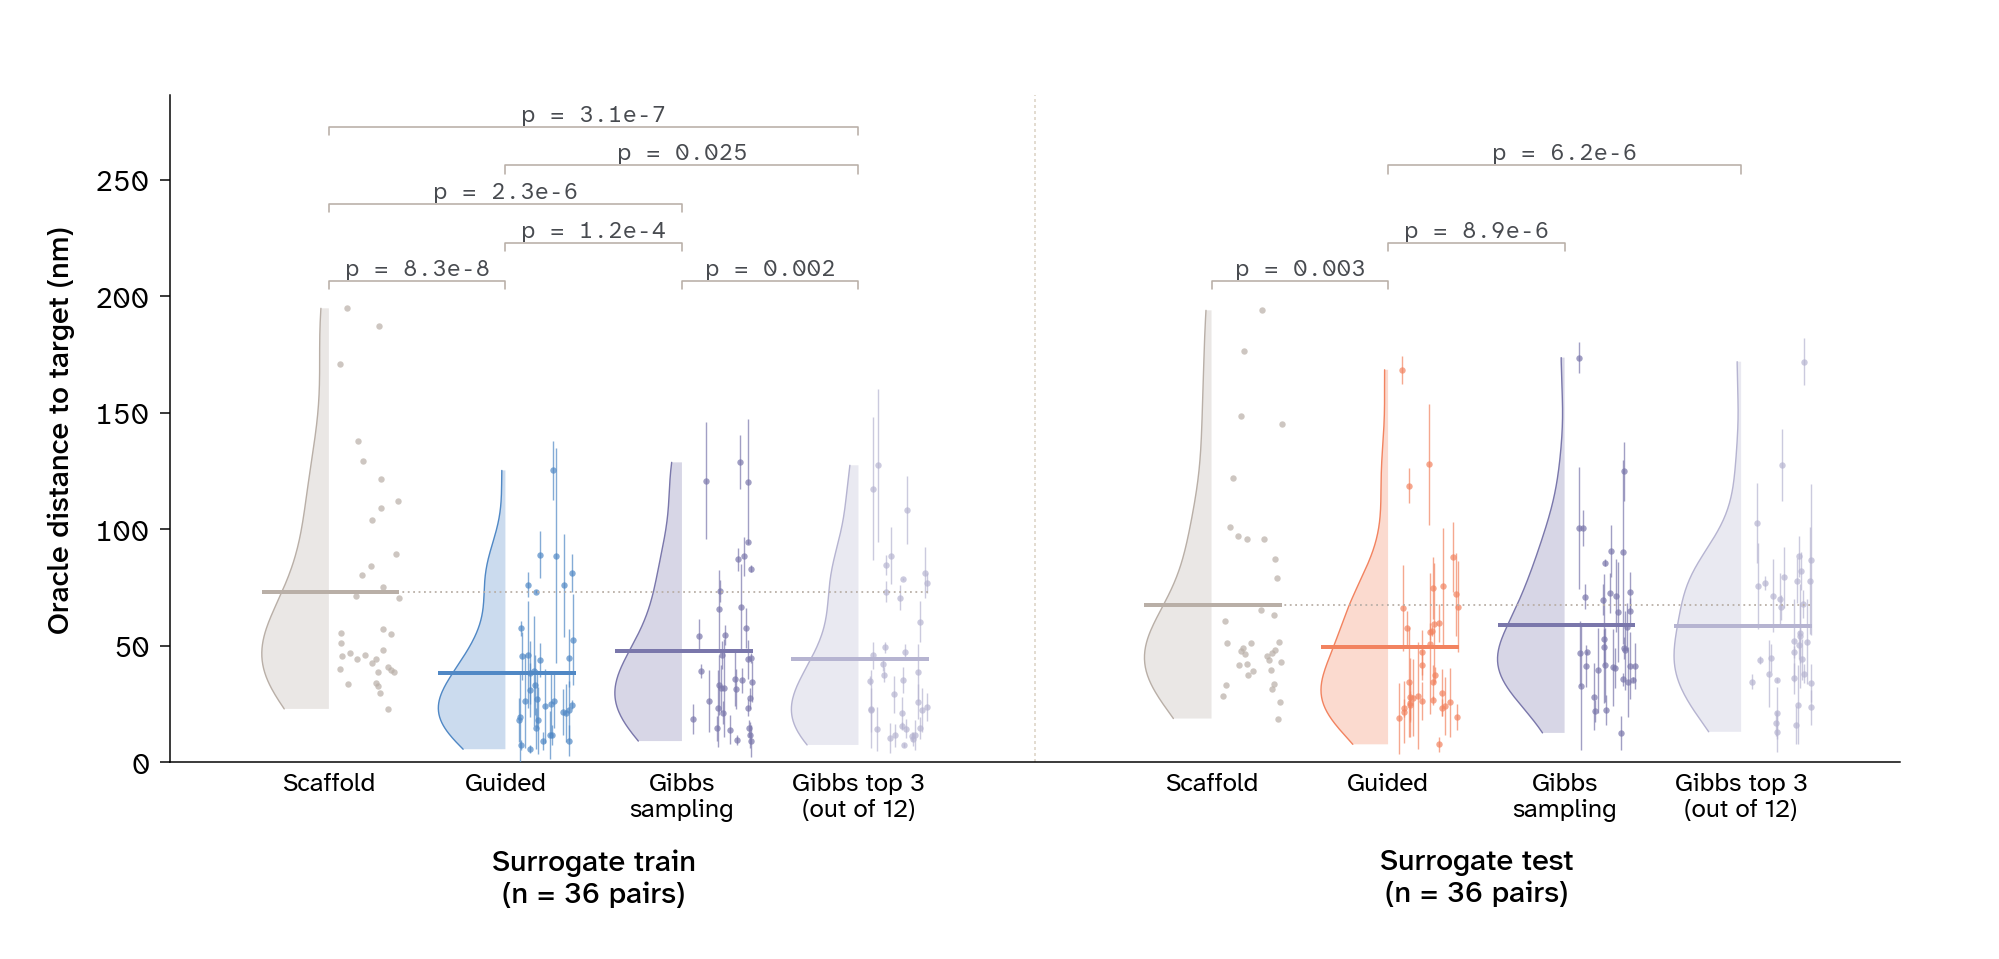

In [24]:
from matplotlib.colors import to_rgb
from scipy.stats import gaussian_kde

# One axis, two conditions, separated by a dashed rule. Within each condition the four groups are the
# unedited scaffold, the guided arm at its final cycle, the unguided control, and the surrogate's top
# 3 of that control's 12 final designs -- the same model as a post-hoc filter. Each group is drawn
# raincloud-style: a half violin on the left of its position and, on the right, one marker per design
# pair at that pair's mean over trials with a bar spanning +- 1 SD across them. The design pair is
# the unit throughout (the cell above says why), so a marker is a task rather than a design, and its
# bar is that task's own run-to-run uncertainty.
GAP = 1                                   # empty x-units between the two conditions
VIOLIN_W, STRIP_W, STRIP_PAD = 0.38, 0.34, 0.06
COND_COLOR = {CONDS[0]: HIGHLIGHT, CONDS[1]: CONTRAST}


def tint(color, f):
    """A fill: the series' own colour lightened towards the page, so markers stay on top of it."""
    return tuple(1 - f + f * c for c in to_rgb(color))


# Colour marks the ARM, not the group: the guided arm takes its condition's colour, both unguided
# groups take aster in both conditions (one series, read across the rule), and the scaffold stays
# neutral because it is the reference rather than a design. The selected group is the paler aster,
# the same family-and-tint convention Figure 4 uses for the guided arm's own top 3 -- lightened less
# than there, because here the colour has to survive being a 3 pt marker rather than a bar.
GROUP_COLOR = {GROUPS[0]: NEUTRAL, GROUPS[2]: CONTROL, GROUPS[3]: tint(CONTROL, 0.55)}


def half_violin(ax, x, v, color, width=VIOLIN_W, n=200):
    """Density of `v`, drawn to the left of `x` only.

    Evaluated between the group's own extremes (seaborn's cut=0 convention), so the violin never
    claims tasks where there are none, and scaled to a fixed maximum width, so violins are read
    against each other by shape rather than by area.
    """
    grid = np.linspace(v.min(), v.max(), n)
    dens = gaussian_kde(v)(grid)
    dens = dens / dens.max() * width
    # The curved side is stroked, the flat side is not: a rule down the group's own position would
    # read as an axis rather than as the edge of a density.
    ax.fill_betweenx(grid, x - dens, x, facecolor=tint(color, 0.30), edgecolor="none", zorder=2)
    ax.plot(x - dens, grid, color=color, lw=0.7, zorder=3)


fig, ax = plt.subplots(figsize=(FULL_WIDE * PX, 480 * PX))
fig.subplots_adjust(left=0.085, right=0.95, top=0.9, bottom=0.205)

rng = np.random.default_rng(RNG_SEED)
xpos = {}
for ci, cond in enumerate(CONDS):
    for gi, g in enumerate(GROUPS):
        x = ci * (len(GROUPS) + GAP) + gi
        xpos[(cond, g)] = x
        v, sd = POINTS[(cond, g)], POINT_SD[(cond, g)]
        col = GROUP_COLOR.get(g, COND_COLOR[cond])
        half_violin(ax, x, v, col)
        ax.errorbar(x + STRIP_PAD + rng.uniform(0, STRIP_W, len(v)), v, yerr=sd, fmt="o", ms=3.2,
                    color=col, ecolor=col, elinewidth=0.7, capsize=0, alpha=0.7, zorder=3)
        ax.plot([x - VIOLIN_W, x + STRIP_PAD + STRIP_W], [v.mean()] * 2, color=col, lw=2,
                solid_capstyle="butt", zorder=4)
    # Where the tasks started, carried across the condition's whole group so every violin can be
    # read against it without counting gridlines.
    x0, x1 = xpos[(cond, GROUPS[0])], xpos[(cond, GROUPS[-1])]
    ax.plot([x0 - VIOLIN_W, x1 + STRIP_PAD + STRIP_W], [POINTS[(cond, GROUPS[0])].mean()] * 2,
            ls=(0, (1, 2)), color=NEUTRAL, lw=0.9, zorder=5)

ax.axvline(0.5 * (xpos[(CONDS[0], GROUPS[-1])] + xpos[(CONDS[1], GROUPS[0])]),
           ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.75, zorder=1)

ax.set_xticks([xpos[(c, g)] for c in CONDS for g in GROUPS])
ax.set_xticklabels([g for c in CONDS for g in GROUPS], fontsize=13)
ax.set_xlim(-0.9, max(xpos.values()) + 0.9)
ax.set_ylabel("Oracle distance to target (nm)")

# The paired t-tests from the cell above, drawn over the two groups each one compares. Only the
# significant ones are drawn -- a bracket is a claim, and "we looked and found nothing" is the
# printout's job. A comparison keeps the SAME level in both conditions, so equal height means equal
# comparison and the two halves can be read against each other; a level is allotted only if the
# comparison is significant somewhere, which is why one side can show a gap where the other has a
# bracket.
#
# Levels are PACKED, not stacked one per comparison: shortest span first, and a bracket takes the
# lowest level it clears horizontally -- its label's width counted as part of it -- rather than
# always opening a new one. The two adjacent-group tests at opposite ends therefore share the bottom
# line, and the stack grows only where spans genuinely overlap: six comparisons in five levels.
Y_TOP_DATA = max((POINTS[k] + np.nan_to_num(POINT_SD[k])).max() for k in POINTS)
BR_Y0 = 1.06 * Y_TOP_DATA
BR_STEP = 0.085 * Y_TOP_DATA
LABEL_W, LABEL_GAP = 1.15, 0.3     # a "p = 1.2e-4" label and the clearance between two, in x units
left = lambda ab: min(GROUPS.index(ab[0]), GROUPS.index(ab[1]))
span = lambda ab: abs(GROUPS.index(ab[1]) - GROUPS.index(ab[0]))


def extent(ab):
    """The x-range a bracket occupies: its own span, widened where the centred label overhangs it."""
    lo, hi = left(ab), left(ab) + span(ab)
    mid = 0.5 * (lo + hi)
    return min(lo, mid - 0.5 * LABEL_W), max(hi, mid + 0.5 * LABEL_W)


rows, LEVEL = [], {}
for ab in sorted((ab for ab in TESTS if any(PAIRED[(c, *ab)]["p"] < ALPHA for c in CONDS)),
                 key=lambda ab: (span(ab), left(ab))):
    lo, hi = extent(ab)
    for i, row in enumerate(rows):
        if all(hi + LABEL_GAP <= l or lo >= h + LABEL_GAP for l, h in row):
            break
    else:
        rows.append([])
        i = len(rows) - 1
    rows[i].append((lo, hi))
    LEVEL[ab] = i
ax.set_ylim(0, BR_Y0 + (len(rows) - 1) * BR_STEP + 0.07 * Y_TOP_DATA)

for cond in CONDS:
    for (a, b), level in LEVEL.items():
        if PAIRED[(cond, a, b)]["p"] >= ALPHA:
            continue
        y = BR_Y0 + level * BR_STEP
        xa, xb = xpos[(cond, a)], xpos[(cond, b)]
        tick = 0.018 * Y_TOP_DATA
        ax.plot([xa, xa, xb, xb], [y - tick, y, y, y - tick], color=NEUTRAL, lw=0.8, zorder=6)
        p = PAIRED[(cond, a, b)]["p"]
        ax.annotate(f"p = {p:.3f}" if p >= 1e-3 else f"p = {p:.1e}".replace("e-0", "e-"),
                    xy=(0.5 * (xa + xb), y), xytext=(0, 1), textcoords="offset points",
                    ha="center", va="bottom", **{**NUMBER_NOTE, "fontsize": 11.5})

# Condition names sit under their own groups rather than in a key.
label_style = dict(fontsize=plt.rcParams["axes.labelsize"], color=plt.rcParams["axes.labelcolor"],
                   fontweight=plt.rcParams["axes.labelweight"])
for cond in CONDS:
    xg = np.mean([xpos[(cond, g)] for g in GROUPS])
    note = "Surrogate train" if cond == CONDS[0] else "Surrogate test"
    ax.text(xg, -0.13, f"{note}\n(n = {len(PER_TASK[cond])} pairs)",
            transform=ax.get_xaxis_transform(), ha="center", va="top", **label_style)

apc.mpl.style_plot(ax, monospaced_axes="y")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="x", length=0)

fig.savefig(f"{FIGDIR}/design_task2_rounds_distance_to_target.svg")
fig.savefig(f"{FIGDIR}/design_task2_rounds_distance_to_target.png", dpi=200)
plt.show()

**Figure 1. On an ordinary target the guidance is the whole of the difference between the arms; on
held-out scaffolds, unguided resampling stops working altogether — and so does using the surrogate
merely to pick the winners out of it.** Oracle distance to the target
for the 36 design pairs of each condition — scaffolds inside the surrogate's train ∪ val refit pool
(left of the dashed rule) and scaffolds held out from it (right). **The design pair is the unit:** a
task's trials are repeated draws on the same scaffold→target problem, so each group is summarised per
task first, and every marker is one pair at its mean over trials with a bar spanning ±1 SD across
them (mean trial SD 12.0-12.2 nm guided, 8.8-11.9 nm unguided). Each group is a raincloud: a half
violin (kernel density over the 36 per-pair means, clipped to their own extremes, scaled to a fixed
maximum width) with those markers beside it and the group mean as a rule across both halves; the
dotted line carries the scaffold mean across the condition. The groups are the unedited scaffold, the
guided arm at its **final cycle** — the intermediate cycle is measured and printed but not drawn,
for the reason in (iv) — the unguided control restricted to its **first 3 trials** so both arms have
the same budget — its 12-trial means, 47.0 and 59.9 nm, differ from the plotted 47.7 and 58.7 by about a
nanometre — and that same control **ranked by the surrogate**: the mean of its best 3 of 12 final
designs, which is the surrogate used as a filter over finished designs rather than inside the search.
The selected group is the one group deliberately not budget-matched, since picking 3 of 12 costs 12
draws, so it is read against the 12-trial mean rather than the 3-trial group beside it; its bars are
the spread over the three designs kept, not over repeated draws (mean 7.6 and 10.8 nm). Colour marks
the arm: guided takes its condition's colour, both unguided groups take aster on both sides with the
selected one paler, the scaffold stays neutral.

Brackets are **paired *t*-tests across the 36 pairs** of a condition, one for each of the six group
comparisons; only significant ones are drawn, with the exact *p*, and a comparison keeps the same
height in both halves, so a gap on one side means that test failed there. Brackets that do not
overlap horizontally share a level, so height says *which* comparison, not how strong it is — the
levels run shortest span at the bottom to longest at the top. Holm-adjusted *p* across each
condition's six tests and a Wilcoxon signed-rank check are in the cell's printout; Holm leaves every
verdict standing, and the one the distribution-free test does not support is the guided arm's 5.6 nm
margin over the selected control on S-pool (*p* = 0.025, Wilcoxon 0.088), read in (iii).

**(i) Both arms move on S-pool; only the guided arm moves on S-test.** Against the scaffold, the
guided final cycle gains 34.5 nm on S-pool (*t*(35) = +6.74, *p* = 8.3 × 10⁻⁸, *d*<sub>z</sub> =
+1.12) and 18.1 nm on held-out scaffolds (*p* = 0.0026, *d*<sub>z</sub> = +0.54). The control gains
25.3 nm on S-pool (*p* = 2.3 × 10⁻⁶) but only **8.7 nm on S-test, which the test cannot separate from
zero** (*p* = 0.13, hence no bracket): 21/36 held-out tasks improve without guidance, against 26/36
with it. This is the sharpest departure from task set 1, where the same control gained 23.7 and 30.6
nm and was decisive in both conditions. With targets a median 79 nm away instead of 190, resampling
the pocket no longer drifts toward the target for free — the free gain the unguided arm collected on
task set 1 was largely a consequence of extreme targets sitting far from the dataset's centre of
mass, which is exactly what a null is supposed to expose.

**(ii) What guidance buys is the same size in both conditions.** Guided minus unguided at the final
cycle is −9.2 nm on S-pool (*t*(35) = −4.33, *p* = 1.2 × 10⁻⁴, *d*<sub>z</sub> = −0.72) and −9.4 nm
on S-test (*t*(35) = −5.19, *p* = 8.9 × 10⁻⁶, *d*<sub>z</sub> = −0.87), with the guided arm closer on
30/36 and 28/36 pairs. The two conditions differ a great deal in their *outcome* (38.4 vs 49.3 nm)
but not at all in the guidance gap, and the same split appears in the arm that never loads the
surrogate. So the S-pool/S-test difference here is a property of the two cohorts' tasks, not evidence
that the surrogate exploits scaffolds it was trained on — task set 1's conclusion, reached from the
other direction.

**(iii) Ranking the control's designs with the surrogate recovers part of the guidance gap on
S-pool and none of it on held-out scaffolds.** Keeping the surrogate's best 3 of the control's 12
final designs improves on averaging all 12 by 3.0 nm on S-pool, 47.0 → 44.1 (*t*(35) = +2.47,
*p* = 0.018, *d*<sub>z</sub> = +0.41, better on 26/36 pairs), and by 1.7 nm on S-test, 59.9 → 58.3,
which the test cannot separate from zero (*p* = 0.13, 22/36). Against the budget-matched 3-trial
control the same selection is +3.6 nm (*p* = 0.0019) and +0.5 nm (*p* = 0.75). What that does to the
comparison the figure is about: on S-pool it cuts the guided arm's margin from 9.2 to 5.6 nm, a
bracket the *t*-test draws and Holm keeps (*p* = 0.025, *d*<sub>z</sub> = −0.39) but the
distribution-free Wilcoxon does not (0.088), and the guided arm is closer on only 22/36 pairs against 30/36 over the unselected control; on S-test
the margin is untouched at 9.0 nm (*t*(35) = −5.31, *p* = 6.2 × 10⁻⁶, *d*<sub>z</sub> = −0.89,
27/36). **The surrogate's ranking transfers no better than its predictions do** — it can pick winners
among designs built on scaffolds it was fitted on and cannot on scaffolds it was not — while the same
model spent *inside* the loop buys the same ~9 nm in both conditions (ii). Selection is also not a
repair for hard tasks: on S-pool it pulls the lower quartile from 25.8 to 15.2 nm and leaves the
upper one where it was (70.3 → 71.2), so it sharpens the pairs that were already working and finds
nothing to pick from on the ones that were not.

**(iv) Only the final cycle is drawn, because the second pass adds nothing measurable**, as on task
set 1: cycle 1 ends at 39.7 and 48.1 nm against the plotted 38.4 and 49.3, a difference of +1.2 nm on
S-pool (*p* = 0.25) and −1.2 nm on S-test (*p* = 0.46). With the window already visited once, a
second pass largely re-proposes what the first accepted. That test is printed in the cell above and
kept out of the Holm family, which is over the four groups the figure actually compares — groups that
differ in *kind* rather than in how far the same search was run.

**(v) Guidance removes bad outcomes rather than producing exceptional ones.** S-pool guided median
26.7 nm, quartiles 19.0-47.7, against the control's 35.4 and 23.4-65.8; S-test guided 36.0
(25.6-61.5) against 48.5 (40.2-71.7). The two lower quartiles are close — an unguided run lands the
occasional near-hit — and the arms separate in the upper half of the distribution.

**(vi) The residual is now within sight of the models' own error.** Designs end 38-49 nm from their
target where the oracle's held-out test MAE is 12.3 nm and the surrogate's is 17.6; task set 1 ended
at ~91 nm, about 7× the oracle's error. Half of these tasks also *start* within 50 nm, so there is
much less room between "unedited scaffold" and "as close as these two models can resolve" — which is
why 10 of the 36 held-out tasks end worse than they started even under guidance. Figure 4 shows what
that looks like pair by pair.

### 1.1 How often a single run improves on its scaffold, and by how much

The counts printed under Figure 1 — 35/36, 34/36, 26/36 — answer *how many design pairs improved* at
the one threshold nobody would defend, zero, and they answer it for a task's **average** draw. Both
halves of that are worth loosening. A design that ended a nanometre closer is not a success when the
oracle judging it has a 12.3 nm test error, and a campaign that can build three proteins cares what
one run returns, not what three of them average to. So this figure changes the unit to the
individual design at the final cycle — 3 per task, 108 per cohort, un-averaged — and sweeps the
threshold instead of fixing it.


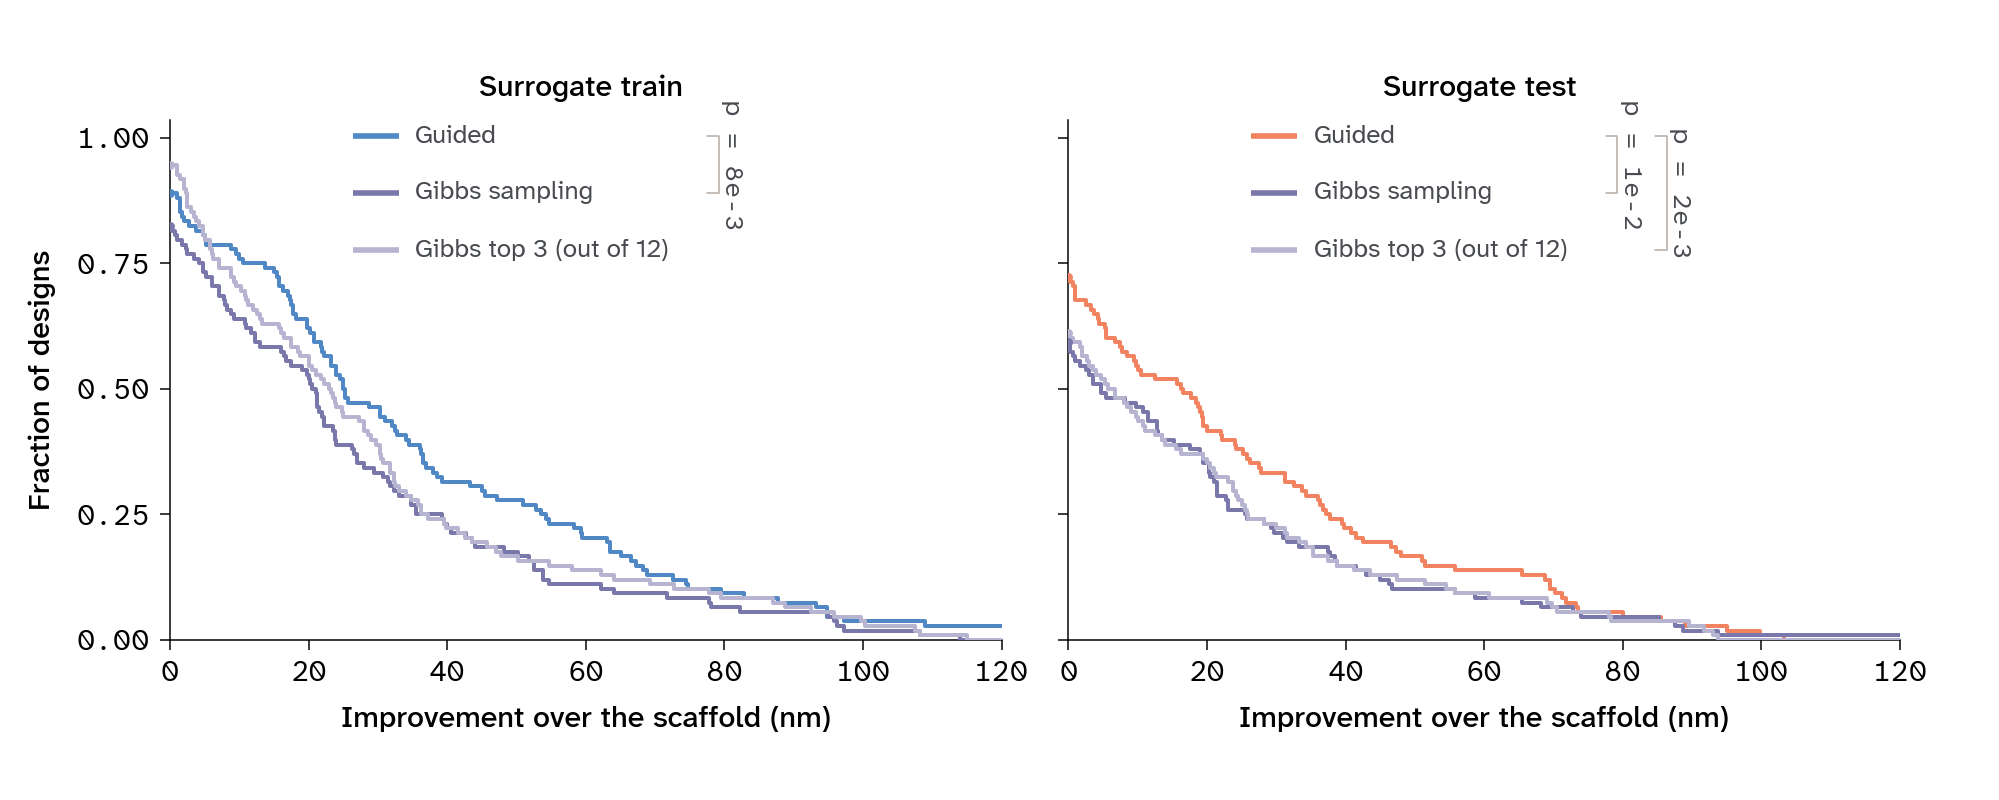

S-pool: fraction of designs improved by at least ...
    Guided                  n = 108 | >=   0nm: 0.89  >=  10nm: 0.76  >=  25nm: 0.50  >=  50nm: 0.28 | median  +24.9nm
    Gibbs sampling          n = 108 | >=   0nm: 0.82  >=  10nm: 0.64  >=  25nm: 0.39  >=  50nm: 0.18 | median  +20.6nm
    Gibbs top 3 (out of 12) n = 108 | >=   0nm: 0.94  >=  10nm: 0.70  >=  25nm: 0.44  >=  50nm: 0.17 | median  +23.0nm
    (all 12 trials)         n = 432 | >=   0nm: 0.83  >=  10nm: 0.63  >=  25nm: 0.41  >=  50nm: 0.19 | median  +20.2nm
S-test: fraction of designs improved by at least ...
    Guided                  n = 108 | >=   0nm: 0.72  >=  10nm: 0.54  >=  25nm: 0.38  >=  50nm: 0.17 | median  +16.3nm
    Gibbs sampling          n = 108 | >=   0nm: 0.59  >=  10nm: 0.46  >=  25nm: 0.26  >=  50nm: 0.10 | median   +4.6nm
    Gibbs top 3 (out of 12) n = 108 | >=   0nm: 0.61  >=  10nm: 0.44  >=  25nm: 0.27  >=  50nm: 0.12 | median   +6.0nm
    (all 12 trials)         n = 432 | >=   0nm: 0.59  >=  10n

In [34]:
# THE UNIT HERE IS THE DESIGN, NOT THE DESIGN PAIR -- the one figure in this notebook where it is.
# Figure 1 asks what a task's typical draw achieves and averages a task's trials to ask it; this asks
# how often a SINGLE RUN hands back something better than the scaffold it started from, which is the
# question a campaign faces when it can build only a handful of proteins. Averaging first would hide
# exactly what that question turns on: the spread between one task's own draws.
#
# Every design is taken at the FINAL cycle and measured against its own task's unedited scaffold (the
# round-0 mean, the same sequence in every trial to within fp16 noise). Each method contributes 3
# designs per task, 108 per cohort -- the guided arm's 3 trials, the control's first 3, and the 3 the
# surrogate picks out of the control's 12. Trial matching matters less here than in Figure 1: taking
# more draws does not shift a distribution over draws, it only estimates it better, and the printout
# carries the control's full 432 designs as a check on that. What the unit does cost is independence
# -- three designs from one task are three draws on one problem -- so the curve is a description of
# the draws, and any test run on it has to treat the task as the cluster.
#
# Both ways of demanding an improvement are computed here and each gets its own figure, because the
# two orderings differ: 18 nm is most of the way home for a design whose scaffold began 40 nm out and
# a rounding error for one that began 190 nm out. Figure 2 draws the demand in NANOMETRES, Figure 3
# the same thing as a SHARE of the distance that design's scaffold started at.
GAIN = {}
for c in CONDS:
    base = PER_TASK[c][GROUPS[0]]                    # each task's unedited scaffold
    for g in GROUPS[1:]:
        d = SOURCE[g][SOURCE[g].cond == c]
        b = base.loc[d.example].to_numpy()
        gain = b - d.peak_err.to_numpy()             # positive = closer than the scaffold began
        GAIN[(c, g)] = {"nm": gain, "pct": 100 * gain / b, "example": d.example.to_numpy()}


def by_task(cond, g, kind):
    """One row per design pair, one column per design: the shape the permutation null needs."""
    d = pd.DataFrame({"e": GAIN[(cond, g)]["example"], "v": GAIN[(cond, g)][kind]})
    return np.stack(d.groupby("e").v.apply(np.asarray).to_numpy())


# --- Do the curves really differ? --------------------------------------------------------------
# The generic test for two survival curves, assuming nothing about their shape: the two-sample
# KOLMOGOROV-SMIRNOV statistic D, the largest vertical gap between them, which is the quantity the
# figures are read for. There is no censoring here, so the survival-analysis machinery a log-rank
# test exists to handle -- and its proportional-hazards assumption -- buys nothing.
#
# Its textbook p value assumes independent observations and these are not: three designs come from
# one design pair. The null is therefore built by PERMUTATION, exchanging the arm labels of a pair's
# six designs within that pair and recomputing D. Every pair keeps three designs in each arm, so the
# resampling respects both the pairing (a pair appears in both arms) and the clustering (a pair's
# draws stay with it), and it assumes only that under the null it does not matter which arm produced
# which of that pair's designs. The test is run separately on each scale: the two differ by a
# per-task rescaling, which reorders the designs, so neither result implies the other.
N_PERM = 10000
TESTS_KS = [(GROUPS[1], GROUPS[2]), (GROUPS[1], GROUPS[3]), (GROUPS[2], GROUPS[3])]
rng_ks = np.random.default_rng(RNG_SEED)


def ks_D(a, b):
    """(largest vertical gap between the two survival curves, the improvement it occurs at)."""
    pooled = np.concatenate([a, b])
    order = np.argsort(pooled, kind="stable")
    step = np.concatenate([np.full(len(a), 1 / len(a)), np.full(len(b), -1 / len(b))])[order]
    run = np.cumsum(step)
    i = np.abs(run).argmax()
    return abs(run[i]), pooled[order][i]


def perm_p(A, B):
    """D, where it falls, and its permutation p, labels exchanged within a design pair."""
    d_obs, at = ks_D(A.ravel(), B.ravel())
    M, k = np.concatenate([A, B], axis=1), A.shape[1]
    hits = sum(ks_D(*(lambda p: (p[:, :k].ravel(), p[:, k:].ravel()))(rng_ks.permuted(M, axis=1)))[0]
               >= d_obs for _ in range(N_PERM))
    return d_obs, at, (hits + 1) / (N_PERM + 1)


def selection_p(cond, kind):
    """The filter needs a different null: its 3 designs are drawn from the same 12 the control's are,
    so an arm label is not exchangeable between them. The question it actually poses is whether
    ranking beats picking 3 of the 12 at random -- so the statistic is D between the selected sample
    and the pool it was selected from, and the null draws the 3 uniformly instead."""
    base = PER_TASK[cond][GROUPS[0]]
    d12 = FINAL_UNGUIDED[FINAL_UNGUIDED.cond == cond]
    b12 = base.loc[d12.example].to_numpy()
    gain = b12 - d12.peak_err.to_numpy()
    pool = pd.DataFrame({"e": d12.example.to_numpy(),
                         "v": gain if kind == "nm" else 100 * gain / b12})
    P = np.stack(pool.groupby("e").v.apply(np.asarray).to_numpy())          # (pairs, 12)
    d_obs, at = ks_D(by_task(cond, GROUPS[3], kind).ravel(), P.ravel())
    hits = sum(ks_D(rng_ks.permuted(P, axis=1)[:, :3].ravel(), P.ravel())[0] >= d_obs
               for _ in range(N_PERM))
    return d_obs, at, (hits + 1) / (N_PERM + 1)


def ks_table(kind):
    """Every comparison on one scale, Holm-adjusted inside each cohort as everywhere else here."""
    out = {}
    for c in CONDS:
        for a, b in TESTS_KS:
            out[(c, a, b)] = (selection_p(c, kind) if (a, b) == TESTS_KS[2]
                              else perm_p(by_task(c, a, kind), by_task(c, b, kind)))
        run = 0.0
        for rank, (p, a, b) in enumerate(sorted((out[(c, a, b)][2], a, b) for a, b in TESTS_KS)):
            run = max(run, min(1.0, (len(TESTS_KS) - rank) * p))
            out[(c, a, b)] = (*out[(c, a, b)], run)
    return out


def p_text(p):
    """One significant figure in exponent form -- 0.0077 reads p = 8e-3 -- as Figure 1 writes its
    own small p values, and short enough to sit beside a bracket rather than beyond the next one."""
    return "p < 1e-4" if p < 1e-4 else "p = " + f"{p:.0e}".replace("e-0", "e-")


# --- The figure, drawn once per scale ------------------------------------------------------------
KEY_ROWS = (0.97, 0.86, 0.75)       # the three series, in axes fraction
KEY_SWATCH, KEY_LABEL_X = (0.22, 0.275), 0.295
BRACKET_X, KEY_TICK = (0.66, 0.72), 0.014


def improvement_curves(kind, grid, xlabel, stem):
    """Both cohorts' survival curves on one scale, with that scale's own tests marked in the key.

    No panel letters: each panel is titled with its cohort and the two are the same plot of the same
    quantity, so a letter would label a distinction the figure is not making.
    """
    ks = ks_table(kind)
    fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDE * PX, 400 * PX), sharey=True)
    fig.subplots_adjust(left=0.085, right=0.95, top=0.85, bottom=0.2, wspace=0.08)

    for ci, cond in enumerate(CONDS):
        ax = axes[ci]
        apc.mpl.style_plot(ax, monospaced_axes="both")
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        for g in GROUPS[1:]:
            v = GAIN[(cond, g)][kind]
            col = GROUP_COLOR.get(g, COND_COLOR[cond])
            ax.plot(grid, (v[:, None] >= grid[None, :]).mean(0), drawstyle="steps-post",
                    color=col, lw=2, zorder=3, solid_joinstyle="round")
            # Where the curve starts: the plain "improved at all" share, the only point on the
            # curve that needs no threshold argued for.
            ax.plot([0], [(v > 0).mean()], marker="o", ms=4.5, color=col, zorder=4)
        ax.set_xlim(grid[0], grid[-1])
        ax.set_ylim(0, 1.035)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
        ax.set_xlabel(xlabel)
        ax.set_title(f"Surrogate {'train' if cond == CONDS[0] else 'test'} ",
                     fontsize=plt.rcParams["axes.labelsize"], pad=12,
                     color=plt.rcParams["axes.labelcolor"])

        # The key is drawn by hand rather than by legend(), because it carries the test as well as
        # the colours: the three series stacked, and a BRACKET joining the pair whose curves the KS
        # test separates, labelled with its permutation p, exactly as Figure 1 brackets its groups.
        # Only significant comparisons are bracketed -- a bracket is a claim -- so an unbracketed
        # pair is one the test could not separate, and the printout carries every number either way.
        # A key per panel, since the guided arm keeps its condition's colour from Figure 1 and its
        # swatch is not the same on both sides.
        for row, g in zip(KEY_ROWS, GROUPS[1:]):
            ax.plot(KEY_SWATCH, [row] * 2, color=GROUP_COLOR.get(g, COND_COLOR[cond]), lw=2.8,
                    transform=ax.transAxes, clip_on=False, solid_capstyle="butt")
            ax.text(KEY_LABEL_X, row, g.replace("\n", " "), transform=ax.transAxes, ha="left",
                    va="center", fontsize=13, color=str(apc.charcoal))
        # Each comparison is placed differently rather than in a shared column: its p runs down the
        # right of ITS OWN bracket, centred on that bracket's span, so which pair a p belongs to is
        # read off its position and not only off the height of the bracket beside it. Turned on its
        # side the label is narrow enough that the outer bracket's line passes it without touching.
        for level, ab in enumerate(TESTS_KS[:2]):
            d, at, p, holm = ks[(cond, *ab)]
            if p >= ALPHA:
                continue
            x, y0, y1 = BRACKET_X[level], KEY_ROWS[0], KEY_ROWS[level + 1]
            ax.plot([x - KEY_TICK, x, x, x - KEY_TICK], [y0, y0, y1, y1], color=NEUTRAL, lw=0.8,
                    transform=ax.transAxes, clip_on=False)
            ax.text(x + 0.016, 0.5 * (y0 + y1), p_text(p), transform=ax.transAxes,
                    ha="center", va="center", rotation=270, **{**NUMBER_NOTE, "fontsize": 13})
        if ci == 0:
            ax.set_ylabel("Fraction of designs")

    fig.savefig(f"{FIGDIR}/{stem}.svg")
    fig.savefig(f"{FIGDIR}/{stem}.png", dpi=200)
    plt.show()
    return ks


def report(kind, marks, unit, ks):
    """The curves at the thresholds worth naming, and the tests behind the marks in the key.

    The control's own 12 trials close each block: if 3 draws describe the arm, the 432-design curve
    should sit on top of the 108-design one.
    """
    for c in CONDS:
        base = PER_TASK[c][GROUPS[0]]
        d12 = FINAL_UNGUIDED[FINAL_UNGUIDED.cond == c]
        b12 = base.loc[d12.example].to_numpy()
        gain = b12 - d12.peak_err.to_numpy()
        pool = gain if kind == "nm" else 100 * gain / b12
        print(f"{c}: fraction of designs improved by at least ...")
        for g in list(GROUPS[1:]) + ["(all 12 trials)"]:
            v = pool if g == "(all 12 trials)" else GAIN[(c, g)][kind]
            print(f"    {_flat(g):23} n = {len(v):3d} | "
                  + "  ".join(f">= {t:>3}{unit}: {(v >= t).mean():.2f}" for t in marks)
                  + f" | median {np.median(v):+6.1f}{unit}")
    print(f"\ntwo-sample Kolmogorov-Smirnov, {N_PERM} permutations within design pair")
    for c in CONDS:
        print(f"  {c}")
        for a, b in TESTS_KS:
            d, at, p, holm = ks[(c, a, b)]
            note = ("  (vs the 12 it was picked from, against random picks)"
                    if (a, b) == TESTS_KS[2] else "")
            print(f"    {_flat(a) + ' vs ' + _flat(b):46} D = {d:.3f} at {at:+6.1f}{unit} | "
                  f"{p_text(p)} (Holm {holm:.4f}){note}")


KS_NM = improvement_curves("nm", np.linspace(0, 120, 481), "Improvement over the scaffold (nm)",
                           "design_task2_improved_vs_threshold")
report("nm", (0, 10, 25, 50), "nm", KS_NM)


**Figure 2. The guided arm's advantage over both controls is not an artefact of where the bar is
set — its curve runs above them at every threshold, and the difference survives a test that assumes
nothing about the curves' shape. Filtering the control's designs with the surrogate does something
different and narrower: on scaffolds the surrogate knows it removes outright failures, and it never
overtakes guidance for the larger moves.** The fraction of a cohort's designs that ended closer to
their target than the unedited scaffold they started from, by at least the improvement on the *x*
axis — **left**, scaffolds inside the surrogate's train ∪ val refit pool; **right**, scaffolds held
out from it.

**The unit is the individual design, not the design pair** — the one figure here where that is true.
Every design is taken at the final cycle and measured against its own task's scaffold, and each
method contributes 3 per task, 108 per cohort: the guided arm's 3 trials, the control's first 3, and
the 3 the surrogate picks out of the control's 12. Nothing is averaged over trials, so a curve
describes what one run returns rather than what three of them agree on. The control's own 12 trials
(432 designs) reproduce its 3-trial curve to within 0.02 at every threshold printed below, so the
truncation is not doing any work. Each curve starts at the dot — the plain "improved at all" share —
and falls to zero at that method's best design, so one method dominates another wherever its curve
runs above; a curve crosses 0.5 at that method's median improvement. Demanding a *share* of the
distance a design's scaffold started at, rather than nanometres, reorders the two controls; those
numbers are printed under the figure and read in (iii).

**The test is the two-sample Kolmogorov–Smirnov statistic** *D*, the largest vertical gap between
two curves, which is the assumption-free version of "one curve sits above the other" and needs
nothing of their shape. There is no censoring here, so the machinery a log-rank test exists to
handle, and its proportional-hazards assumption, would buy nothing. Its textbook *p* would be wrong
in the other direction, though: three designs come from one design pair, so the null is built by
permutation instead — exchanging the arm labels of a pair's six designs *within that pair*, 10,000
times, which respects both the pairing and the clustering. The filter needs a different null, since
its 3 designs are drawn from the same 12 the control's are and an arm label is not exchangeable
between them; there the statistic is *D* between the selected sample and the 12-design pool it came
from, against the same *D* when the 3 are picked at random. The key carries the verdict the way
Figure 1's brackets do: a bracket joins the two series a test separates, labelled with its
permutation *p* written to one significant figure, and **only significant comparisons are
bracketed** — an unbracketed pair is one the test could not separate. The filter's own test joins no
two curves, so it is not bracketed at all; it and every number behind the marks — *D*, where the
largest gap falls, and Holm across each cohort's three tests — are in the printout.

**(i) At a threshold of zero, filtering looks best and means least.** On S-pool the surrogate's top 3
improve at all on 0.94 of designs against the guided arm's 0.89 and the raw control's 0.82: ranking
12 finished designs is an effective way to *throw out the failures*, which is the one thing a
post-hoc filter can do without any ability to aim. Against random picks from the same 12 that
selection is decisive (*D* = 0.130, *p* < 0.0001), and the gap falls at +0.6 nm — precisely at the
improved/not-improved line, not out among the large moves. The ordering reverses as soon as the
demand exceeds a rounding error: by 10 nm it is 0.76 guided against 0.70 filtered, and it never
reverses back. On held-out scaffolds the filter cannot even do that much — 0.61 against the raw
control's 0.59, with the guided arm at 0.72, and selection no better than chance (*D* = 0.053,
*p* = 0.38).

**(ii) The guided arm leads at every threshold, and the whole-curve test agrees.** S-pool, guided /
Gibbs / Gibbs top 3: 0.76 / 0.64 / 0.70 at 10 nm, 0.50 / 0.39 / 0.44 at 25 nm, 0.28 / 0.18 / 0.17 at
50 nm; S-test 0.54 / 0.46 / 0.44, then 0.38 / 0.26 / 0.27, then 0.17 / 0.10 / 0.12. Against the raw
control the KS test separates the arms in both cohorts (*D* = 0.167, *p* = 0.008 on S-pool;
*D* = 0.148, *p* = 0.011 on S-test), and against the filtered control it separates them on held-out
scaffolds (*D* = 0.157, *p* = 0.002) but **not** on training-pool ones (*D* = 0.120, *p* = 0.11) —
the same verdict Figure 1 (iii) reaches from the pair-level means, reached here without averaging.
Median improvement is +24.9 nm guided against +20.6 and +23.0 on S-pool, and +16.3 nm against +4.6
and +6.0 on held-out scaffolds, the largest single-number gap in the figure.

**(iii) In relative terms the filter recovers most of the gap on S-pool and none of it on S-test.**
Closing at least a quarter of the scaffold's distance: 0.70 / 0.57 / 0.64 on S-pool against
0.49 / 0.36 / 0.34 on S-test; at half the distance, 0.49 / 0.32 / 0.42 and 0.30 / 0.17 / 0.19. Median
relative improvement is +47.3% / +29.4% / +38.9% on S-pool and +22.1% / +8.6% / +10.5% on S-test.
This is Figure 1 (iii) at the level of single runs: the surrogate ranks designs usefully on scaffolds
it was fitted on and not on scaffolds it was not.

**(iv) The failure rate is what the averages hide.** 11% of guided designs on training-pool scaffolds
end *further* from the target than the scaffold they started from, against 18% for the raw control
and 6% for the filtered one; on held-out scaffolds those become 28%, 41% and 39%. Figure 1 counts
26/36 held-out pairs as improved because averaging three draws rescues a task in which one draw was
bad — at the level of the run, that is not what a campaign would see.


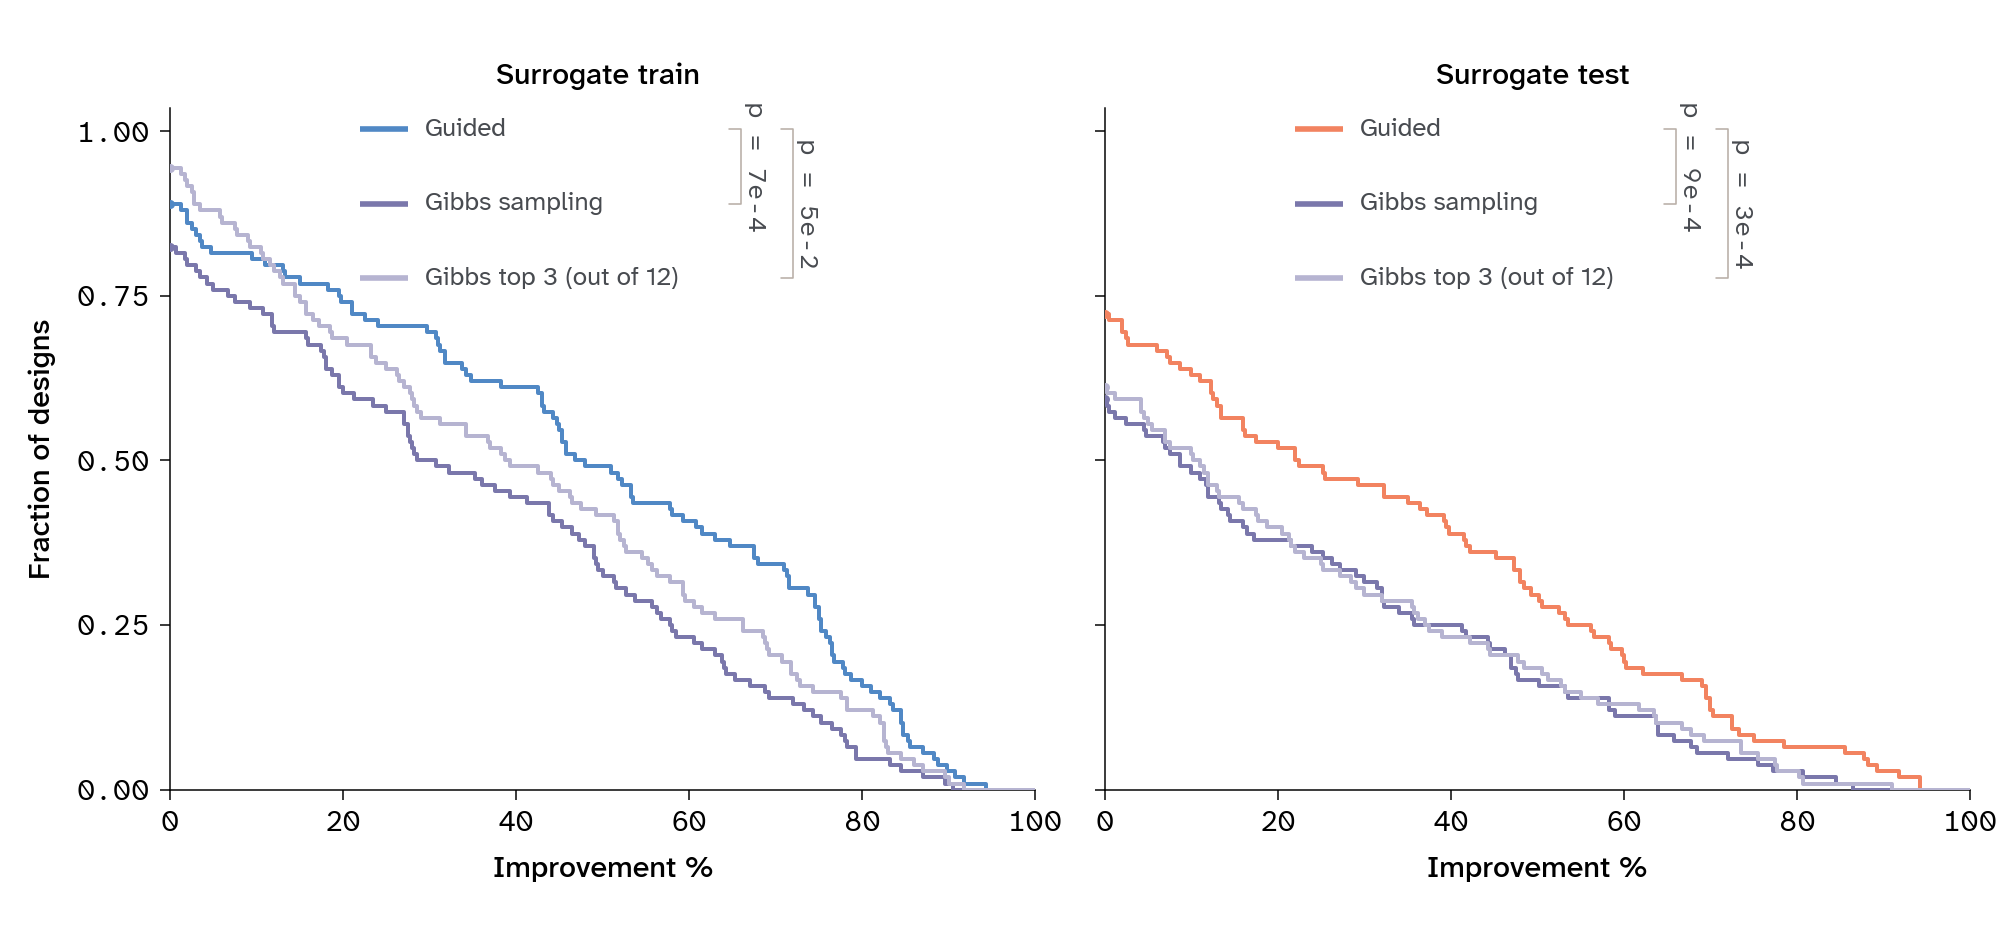

S-pool: fraction of designs improved by at least ...
    Guided                  n = 108 | >=   0%: 0.89  >=  25%: 0.70  >=  50%: 0.49  >=  75%: 0.26 | median  +47.3%
    Gibbs sampling          n = 108 | >=   0%: 0.82  >=  25%: 0.57  >=  50%: 0.32  >=  75%: 0.11 | median  +29.4%
    Gibbs top 3 (out of 12) n = 108 | >=   0%: 0.94  >=  25%: 0.64  >=  50%: 0.42  >=  75%: 0.15 | median  +38.9%
    (all 12 trials)         n = 432 | >=   0%: 0.83  >=  25%: 0.56  >=  50%: 0.35  >=  75%: 0.12 | median  +32.1%
S-test: fraction of designs improved by at least ...
    Guided                  n = 108 | >=   0%: 0.72  >=  25%: 0.49  >=  50%: 0.30  >=  75%: 0.07 | median  +22.1%
    Gibbs sampling          n = 108 | >=   0%: 0.59  >=  25%: 0.36  >=  50%: 0.17  >=  75%: 0.05 | median   +8.6%
    Gibbs top 3 (out of 12) n = 108 | >=   0%: 0.61  >=  25%: 0.34  >=  50%: 0.19  >=  75%: 0.06 | median  +10.5%
    (all 12 trials)         n = 432 | >=   0%: 0.59  >=  25%: 0.33  >=  50%: 0.16  >=  75%: 0.05

In [32]:
# The same figure with the demand expressed as a SHARE of the distance that design's scaffold
# started at, rather than in nanometres. Nothing about the designs changes; the x axis is rescaled
# per design pair, which reorders them -- a 20 nm move is 50% of a 40 nm gap and 10% of a 190 nm one
# -- so the curves are genuinely different curves and the tests are re-run rather than carried over.
KS_PCT = improvement_curves("pct", np.linspace(0, 100, 401),
                            "Improvement %",
                            "design_task2_improved_vs_threshold_pct")
report("pct", (0, 25, 50, 75), "%", KS_PCT)


**Figure 3. Asked for a share of the distance it had to travel rather than a number of nanometres,
the guided arm still leads: it closes more of each scaffold's gap to the target than either control,
on scaffolds the surrogate was fitted on and on scaffolds it never saw.** Figure 2 redrawn with the
demand on the *x* axis expressed as a percentage of the distance that design's own scaffold started
from its target — 0% is "no better than the scaffold it was built from", 100% is "landed on the
target exactly". The *y* axis is unchanged: the fraction of a cohort's designs that closed at least
that share of the gap, so a curve runs from the plain "improved at all" share on the left down to
zero at that method's best design, and one method beats another wherever its curve sits higher.
**Left**, scaffolds inside the surrogate's train ∪ val refit pool; **right**, scaffolds held out from
it.

Everything except the *x* axis is Figure 2's: the unit is the individual design at the final cycle,
each method contributing 3 per task and 108 per cohort — the guided arm's 3 trials (aegean on
S-pool, amber on S-test), the unguided control's first 3 (aster), and the 3 the surrogate picks
out of that control's 12 (pale aster) — with nothing averaged over trials. The rescaling is not
cosmetic, though: dividing by each pair's own starting distance reorders the designs, because 20 nm
is half of a 40 nm gap and a tenth of a 190 nm one. These are therefore different curves from Figure
2's, and every test behind them is re-run rather than carried over.

The typical guided design closes **47.3%** of its scaffold's gap on train-pool scaffolds and
**22.1%** on held-out ones, against 29.4% and 8.6% for unguided Gibbs sampling and 38.9% and 10.5%
for the surrogate's top 3 of 12. Closing at least half the gap: 0.49 of guided designs on train-pool
scaffolds against 0.32 unguided and 0.42 filtered, and 0.30 on held-out scaffolds against 0.17 and
0.19. The control's own 12 trials (432 designs) track its 3-trial curve to within 0.03 at every
threshold printed below, so the budget-matching does not shape the comparison.

Brackets carry the two-sample Kolmogorov–Smirnov test of Figure 2 — *D*, the largest vertical gap
between two curves, against a null that exchanges the arm labels of a design pair's six designs
*within that pair*, 10,000 times — labelled with the permutation *p* to one significant figure and
Holm-adjusted within each cohort; **only significant comparisons are bracketed**. On this scale the
guided arm separates from *both* controls in *both* cohorts, including from the filtered control on
train-pool scaffolds (*D* = 0.148, *p* = 0.049), which the nanometre axis of Figure 2 could not
separate (*p* = 0.11) — demanding a share of the journey is the harder test to pass by starting close
to the target. The filter's advantage remains concentrated where it means least: judged against
random picks from the same 12 designs it is decisive on train-pool scaffolds (*D* = 0.127,
*p* = 0.0003), but its largest gap falls at **+1.1%**, essentially at the improved/not-improved line,
and on held-out scaffolds it is indistinguishable from picking 3 at random (*D* = 0.049, *p* = 0.62).
Every number behind the marks, and the thresholds not named here, are in the printout.

## 2. How far each method landed from its target, pair by pair

Figure 1 asks whether the guided search moves and Figure 2 how often the move is large enough to be
worth naming. This one asks how well it arrives, over the three
methods a campaign could actually deploy on the identical 72 tasks: the single design the surrogate
ranks first, the mean of its top 3, and the mean of the unguided arm's 12 final designs. Every bar is
one design pair, drawn as the **absolute** offset from that pair's own target, so zero is a hit.

The control enters here as the plain mean of its 12, not as Figure 1's surrogate-selected top 3: the
question this figure asks is what each *arm* delivers, and the selected group belongs to the guided
arm's model. Figure 1 (iii) is where the two are weighed against each other.

The bars are grouped into one block per method rather than one group per pair, which makes the
figure a comparison of **distributions**: how much of a block sits under the 25 nm rule, where its
body lies, and how far its tail runs. Each block is ranked by its own result, best pair to worst, so
no method is flattered by an ordering borrowed from another and the three shapes can be read against
each other directly. The cost of that choice is that a given slot is a different pair in each block —
the pairing is preserved in the printout's paired tests, not on the x-axis.

The S-pool / S-test split is deliberately absent: Figure 1 carries that contrast, and mixing it in
here would put two questions on one axis. Per-condition means are in the printout.

Direction is dropped from the artwork and kept in the printout, where the correlations do the work
an absolute axis cannot. A design peak correlated with its **target's** says the method is steered;
one correlated with its **scaffold's** says it is the starting protein resampled. A search with no
aim can still move a long way — Figure 1's control did — but it has no reason to end up anywhere in
particular, and on an absolute axis a lucky landing and an aimed one look identical.

In [27]:
# One row per design pair, holding the three methods Figure 4 compares -- the single design the
# surrogate ranks first, the mean of its top 3, and the mean of the unguided arm's 12 final designs
# -- beside the target all three were aimed at. Both peaks travel together, so a row carries ex
# and em.
def series_stats(df, prefix):
    g = df.groupby("example")
    out = pd.DataFrame(index=g.size().index)
    for peak in ("ex", "em"):
        out[f"{prefix}_{peak}"] = g[f"pred_{peak}"].mean()
    return out


top1 = top_k_by_surrogate(guided, 1)
pairs = (guided[guided["round"] == 0].drop_duplicates("example")
         .set_index("example")[["cond", "scaffold_name", "target_name", "target_ex", "target_em",
                                 "scaffold_ex", "scaffold_em"]]
         .join(series_stats(top1, "sel"))
         .join(series_stats(top3, "top3"))
         .join(series_stats(FINAL_UNGUIDED, "gibbs")))

# THE FIGURE'S QUANTITY: the ABSOLUTE offset from the target, per peak, plus the same
# 0.5(|dex| + |dem|) combination the design loop scores with. Direction is dropped from the artwork
# -- zero is a hit and taller is worse, whichever way the design missed -- but the printout keeps
# it, because which way a method misses is what the compression numbers at the bottom are about.
METHODS = [("sel", "Guided, surrogate's top 1"),
           ("top3", f"Guided, mean of top {TOP_K}"),
           ("gibbs", f"Unguided (Gibbs), mean of {unguided.trial.nunique()}")]
SHORT = {"sel": "guided top 1", "top3": f"guided top {TOP_K}", "gibbs": "unguided"}
for prefix, _ in METHODS:
    for peak in ("ex", "em"):
        pairs[f"d_{prefix}_{peak}"] = (pairs[f"{prefix}_{peak}"] - pairs[f"target_{peak}"]).abs()
    pairs[f"d_{prefix}"] = 0.5 * (pairs[f"d_{prefix}_ex"] + pairs[f"d_{prefix}_em"])

ON_TARGET = 25.0                   # "landed on it": both peaks inside 25 nm, as in Section 9
pairs = pairs.sort_values("d_sel").reset_index()   # the printout's order; the figure ranks per block

# Targets are drawn uniformly from each scaffold's qualifying set here, so unlike Section 9 -- where
# the argmax of distance kept landing on the handful of proteins at the ends of the spectrum -- the
# task set spends its targets on nearly as many distinct proteins as it has tasks.
tgt = pairs.groupby(["target_name", "target_ex", "target_em"]).size().sort_values(ascending=False)
print(f"{len(pairs)} design pairs | {len(tgt)} distinct targets over {pairs.scaffold_name.nunique()} "
      f"distinct scaffolds; the top 3 account for {tgt.head(3).sum()}: "
      + ", ".join(f"{n} ({ex:.0f}/{em:.0f} nm) x{k}" for (n, ex, em), k in tgt.head(3).items()))

print("\ndistance from the target, over all 72 pairs")
for prefix, name in METHODS:
    d = pairs[f"d_{prefix}"]
    near = (pairs[f"d_{prefix}_ex"] < ON_TARGET) & (pairs[f"d_{prefix}_em"] < ON_TARGET)
    # The per-peak counts are what the figure shows directly: how much of a block sits under the
    # dashed rule. The both-peaks count is the stricter claim and is smaller than either.
    under = ", ".join(f"{k} {int((pairs[f'd_{prefix}_{k}'] < ON_TARGET).sum())}"
                      for k in ("ex", "em"))
    print(f"  {name:28} {d.mean():5.1f} nm mean, {d.median():5.1f} median, IQR "
          f"{d.quantile(.25):.1f}-{d.quantile(.75):.1f} | ex {pairs[f'd_{prefix}_ex'].mean():5.1f}, "
          f"em {pairs[f'd_{prefix}_em'].mean():5.1f} | under {ON_TARGET:.0f} nm: {under}, "
          f"both {int(near.sum())} of {len(pairs)}")
for c in CONDS:
    g = pairs[pairs.cond == c]
    print(f"  {c} ({len(g)} pairs): "
          + ", ".join(f"{SHORT[p]} {g[f'd_{p}'].mean():.1f}" for p, _ in METHODS) + " nm")

# The comparison the figure is drawn to support, paired over the 72 tasks every method ran.
for a, b in (("sel", "gibbs"), ("sel", "top3")):
    x, y = pairs[f"d_{a}"].to_numpy(), pairs[f"d_{b}"].to_numpy()
    r = ttest_rel(x, y)
    print(f"  {SHORT[a]} vs {SHORT[b]}, paired: {(x - y).mean():+6.1f} nm | t({len(x) - 1}) = "
          f"{r.statistic:+5.2f}, p = {r.pvalue:.2g} (Wilcoxon {wilcoxon(x, y).pvalue:.2g}) | "
          f"{SHORT[a]} closer on {int((x < y).sum())}/{len(x)}")

# Where the accuracy comes from. r against the TARGET says whether a method is steered; r against
# the SCAFFOLD says whether it is just the starting protein resampled -- the distinction the bars
# cannot show, since a design can sit close to its target by luck.
print("\nsteered, or just resampled?")
for prefix, name in METHODS:
    row = []
    for peak in ("ex", "em"):
        v = pairs[f"{prefix}_{peak}"].to_numpy()
        row.append(f"{peak} r_target {np.corrcoef(v, pairs[f'target_{peak}'].to_numpy())[0, 1]:+.2f}, "
                   f"r_scaffold {np.corrcoef(v, pairs[f'scaffold_{peak}'].to_numpy())[0, 1]:+.2f}, "
                   f"span {v.max() - v.min():.0f} nm")
    print(f"  {name:28} " + " | ".join(row))
print(f"  {'targets':28} ex span {pairs.target_ex.max() - pairs.target_ex.min():.0f} nm "
      f"({pairs.target_ex.min():.0f}-{pairs.target_ex.max():.0f}) | em span "
      f"{pairs.target_em.max() - pairs.target_em.min():.0f} nm "
      f"({pairs.target_em.min():.0f}-{pairs.target_em.max():.0f})")
# The crossover the absolute axis hides: below it the design is too red, above it too blue.
red = pairs[pairs.sel_em > pairs.target_em]
blue = pairs[pairs.sel_em < pairs.target_em]
print(f"  surrogate's top 1 is redder than its target on {len(red)}/{len(pairs)} pairs (target em "
      f"{red.target_em.min():.0f}-{red.target_em.max():.0f} nm) and bluer on {len(blue)} "
      f"(target em {blue.target_em.min():.0f}-{blue.target_em.max():.0f} nm)")
# How far each pair had to travel, which is the axis task set 2 exists to change.
dist = np.hypot(pairs.target_ex - pairs.scaffold_ex, pairs.target_em - pairs.scaffold_em)
print(f"  scaffold->target distance (dataset peaks): min {dist.min():.0f}, median {dist.median():.0f}, "
      f"max {dist.max():.0f} nm | task set 1's median was 190")

72 design pairs | 60 distinct targets over 72 distinct scaffolds; the top 3 account for 6: BFP5 (385/450 nm) x2, D10 (433/475 nm) x2, GdT (476/500 nm) x2

distance from the target, over all 72 pairs
  Guided, surrogate's top 1     40.9 nm mean,  32.5 median, IQR 17.4-61.1 | ex  42.4, em  39.5 | under 25 nm: ex 26, em 32, both 21 of 72
  Guided, mean of top 3         41.6 nm mean,  34.0 median, IQR 18.2-58.8 | ex  43.3, em  39.8 | under 25 nm: ex 28, em 34, both 22 of 72
  Unguided (Gibbs), mean of 12  52.5 nm mean,  43.3 median, IQR 30.1-74.2 | ex  55.7, em  49.3 | under 25 nm: ex 13, em 17, both 8 of 72
  S-pool (36 pairs): guided top 1 34.3, guided top 3 36.5, unguided 45.6 nm
  S-test (36 pairs): guided top 1 47.6, guided top 3 46.7, unguided 59.5 nm
  guided top 1 vs unguided, paired:  -11.6 nm | t(71) = -5.58, p = 4.1e-07 (Wilcoxon 1.4e-06) | guided top 1 closer on 53/72
  guided top 1 vs guided top 3, paired:   -0.7 nm | t(71) = -0.60, p = 0.55 (Wilcoxon 0.56) | guided top 1 clos

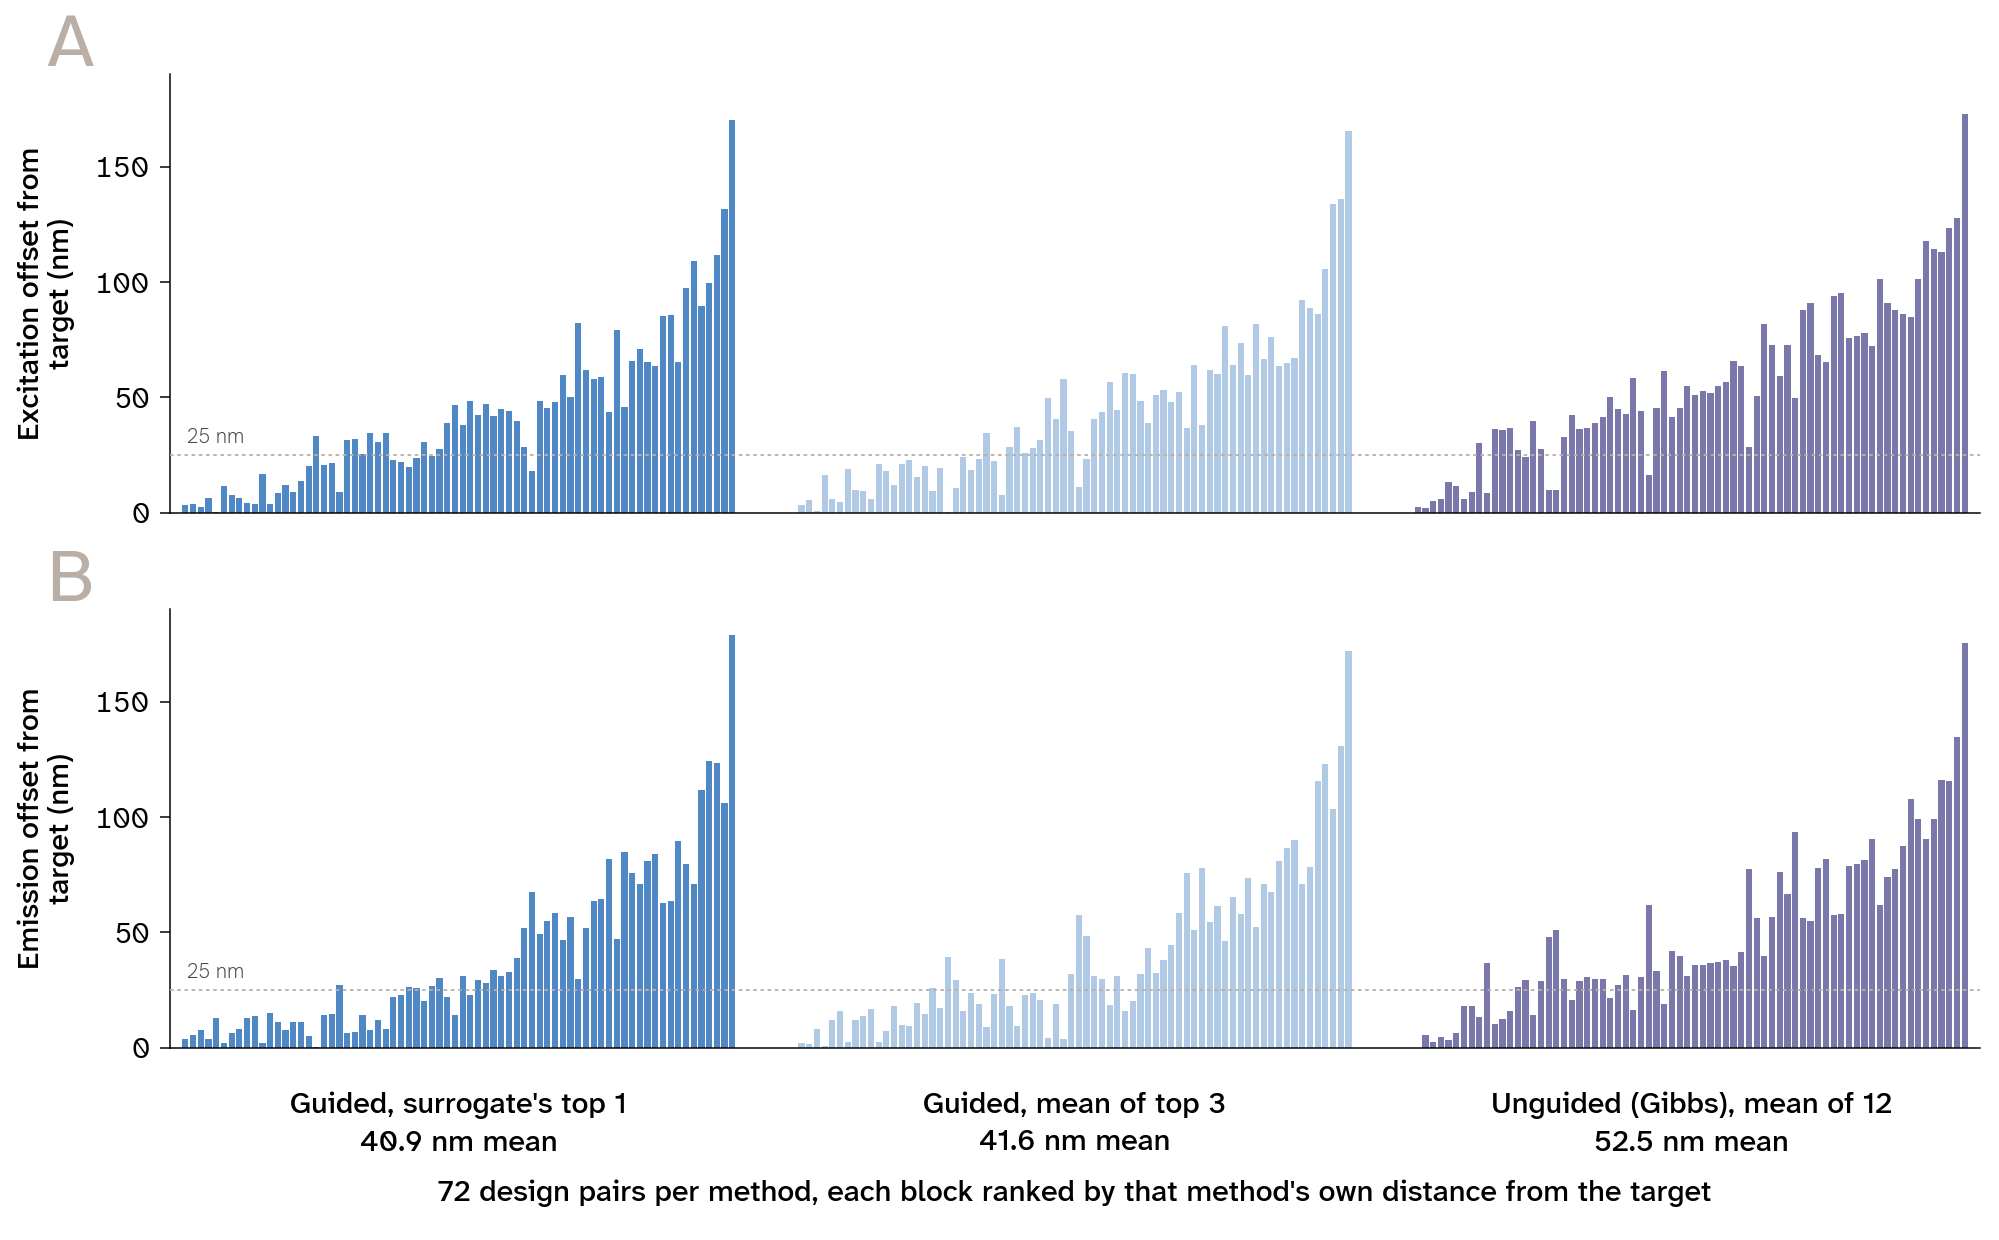

In [28]:
# Two panels, one per peak, and inside each a BLOCK PER METHOD rather than a group per pair. Every
# bar is still one design pair's distance from its own target -- zero is a hit, taller is worse
# whichever way it missed -- but a method's 72 pairs stand together, so a block is the whole
# distribution of outcomes that method produced and the three are compared as shapes: how much of a
# block lies under the dashed rule, and how far its tail runs.
#
# Each block is ranked by its OWN result, best pair to worst, so no method is flattered by an
# ordering borrowed from another. The rank uses the same 0.5(|dex| + |dem|) combination in both
# panels, so a pair holds its slot from excitation to emission within its block -- the blocks are
# therefore near-monotone rather than exactly so, and a spike is a pair that missed on one peak only.
# Only positions are drawn, not spreads: Figure 1 already shows what the trials scatter.
#
# Colour marks the method, redundantly with the block labels, so a block read on its own still
# matches Figure 1's palette: the two guided methods share aegean (the paler is the top-3 mean, same
# family because it is the same search) and the control keeps aster. No key -- the blocks are
# labelled directly, which is fewer hops than a swatch. The S-pool / S-test split is deliberately
# absent; Figure 1 carries that contrast.
METHOD_COLOR = {"sel": HIGHLIGHT, "top3": tint(HIGHLIGHT, 0.45), "gibbs": CONTROL}
RULE_LABEL = dict(fontsize=10.5, fontweight="ultralight", color=str(apc.charcoal))
BLOCK_GAP = 8                      # empty pair slots between two methods
N = len(pairs)
ORDER = {p: np.argsort(pairs[f"d_{p}"].to_numpy(), kind="stable") for p, _ in METHODS}
XPOS = {p: np.arange(N) + i * (N + BLOCK_GAP) for i, (p, _) in enumerate(METHODS)}
YMAX = 10 * np.ceil(max(pairs[f"d_{p}_{k}"].max()
                        for p, _ in METHODS for k in ("ex", "em")) / 10) + 10

fig, axes = plt.subplots(2, 1, figsize=(FULL_WIDE * PX, 620 * PX), sharex=True, sharey=True)
fig.subplots_adjust(left=0.085, right=0.99, top=0.94, bottom=0.155, hspace=0.22)

for ax, (peak, name, letter) in zip(axes, [("ex", "Excitation", "A"), ("em", "Emission", "B")]):
    for prefix, _ in METHODS:
        ax.bar(XPOS[prefix], pairs[f"d_{prefix}_{peak}"].to_numpy()[ORDER[prefix]],
               width=0.8, color=METHOD_COLOR[prefix], linewidth=0, zorder=2)
    # The threshold the "landed on it" counts use. Across blocks it reads as a waterline: the run of
    # bars under it is how many pairs that method placed within 25 nm on this peak.
    ax.axhline(ON_TARGET, ls=(0, (2, 2)), color=NEUTRAL, lw=0.9, zorder=4)
    ax.annotate(f"{ON_TARGET:.0f} nm", xy=(0, ON_TARGET), xytext=(1, 4),
                textcoords="offset points", ha="left", va="bottom", **RULE_LABEL)
    ax.set_xlim(-2, XPOS[METHODS[-1][0]].max() + 2)
    ax.set_ylim(0, YMAX)
    ax.set_ylabel(f"{name} offset from\ntarget (nm)")
    apc.mpl.style_plot(ax, monospaced_axes="y")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="x", length=0)
    ax.set_xticks([])
    panel_letter(ax, letter, dx=-62, dy=-2)

# Method names under the bottom panel in place of task labels, each with the mean of the block above
# it, so the number the eye is averaging towards sits with the distribution rather than in a key.
label_style = dict(fontsize=plt.rcParams["axes.labelsize"], color=plt.rcParams["axes.labelcolor"],
                   fontweight=plt.rcParams["axes.labelweight"])
for prefix, lab in METHODS:
    axes[1].text(XPOS[prefix].mean(), -0.10, f"{lab}\n{pairs['d_' + prefix].mean():.1f} nm mean",
                 transform=axes[1].get_xaxis_transform(), ha="center", va="top", linespacing=1.5,
                 **label_style)
axes[1].text(0.5, -0.30, f"{N} design pairs per method, each block ranked by that method's own "
             "distance from the target", transform=axes[1].transAxes, ha="center", va="top",
             **label_style)

fig.savefig(f"{FIGDIR}/design_task2_offset_from_target_ranked.svg")
fig.savefig(f"{FIGDIR}/design_task2_offset_from_target_ranked.png", dpi=200)
plt.show()

**Figure 4. Guidance is worth about 12 nm per design pair, and it is worth most on the pairs the
campaign already solves — on the hardest third the two arms fail together.** Absolute offset from the
target for the three methods a campaign could deploy, one block each: the guided arm's
surrogate-ranked best design (aegean), the mean of its top 3 (pale aegean), and the mean of the
unguided arm's 12 final designs (aster), every bar one of the 72 design pairs — **(A)** excitation,
**(B)** emission. Zero is a hit, taller is worse whichever way the design missed, and the dashed rule
is the 25 nm "landed on it" threshold, so the run of bars beneath it in a block is that method's hit
count on that peak. Each block is ranked by its own combined distance, best pair to worst, which
means no method is flattered by another's ordering but also that a slot is a *different* pair in each
block; the pairing is kept in the paired tests below, not on the x-axis. The rank is shared between
panels, so a pair holds its slot from **(A)** to **(B)** within its block and a lone spike is a pair
that missed on one peak only. Spreads are omitted because Figure 1 already shows what the trials
scatter, and the S-pool / S-test split is left to Figure 1 as well.

**The guided pick is 40.9 nm from its target on average** (median 32.5, IQR 17.4-61.1) against
**52.5 nm** for the unguided control (median 43.3) — paired over the 72 tasks, −11.6 nm, *t*(71) =
−5.58, *p* = 4 × 10⁻⁷ (Wilcoxon 1 × 10⁻⁶), closer on 53/72. Under the rule it holds 26 pairs in
excitation and 32 in emission against the control's 13 and 17, and **21 of 72 on both peaks at once
against 8**; on task set 1 it managed 0 of 72. Both cohorts move together — S-pool 34.3 vs 45.6 nm,
S-test 47.6 vs 59.5 — so the advantage is not a memorisation effect.

**Averaging the surrogate's top 3 changes nothing**: 41.6 nm and 22/72 inside the rule on both peaks,
and paired against the top 1 it is −0.7 nm, *p* = 0.55. The two guided blocks are the same shape from
end to end. Its first choice is as good as its short list, so the selection rule is not what limits
the campaign.

**The advantage shrinks exactly where it would be most useful.** Splitting the pairs into thirds by
the guided arm's own distance, it beats the control by 15.9 nm on the easiest 24 (11.1 vs 27.0 nm),
by 13.7 on the middle 24, and by only **5.2 on the hardest 24** (79.3 vs 84.6, closer on 15/24).
Those hardest pairs ask for a mean 146 nm journey against 73 nm for the easiest, and past roughly
100 nm the two methods stall in the same place — which is why the right-hand tails of the three
blocks converge while their bodies do not. What this figure calls difficulty is mostly distance.

**An absolute axis cannot separate aim from luck; the correlations can.** The guided top-1 peak
correlates **+0.60** (excitation) and **+0.51** (emission) with its target, against +0.29 and +0.58
with its own scaffold. The unguided mean is the mirror image — +0.19 and +0.26 against the target,
**+0.62 and +0.81 against the scaffold** — the starting protein resampled, which is what "moved a
long way with no aim" looks like once the pairs are kept intact. Both arms still compress toward the
middle of the spectrum, spanning 146/136 nm (guided) and 129/103 (unguided) where the targets span
228/222, and the guided pick is redder than its target on 43/72 pairs and bluer on 29: a pocket edit
inside a fixed scaffold moves a design a long way, but it pulls toward where fluorescent proteins
usually are.

**The tasks behind this figure are 60 distinct targets over 72 pairs**, the most-used appearing
twice, at a median scaffold→target distance of 79 nm. Section 9's task set had 15 distinct targets
over the same number of pairs — Sumire alone took 20 — at a median distance of 190 nm, because
pairing each scaffold with its *most distant* target keeps landing on the same handful of extreme
proteins. That is the difference task set 2 was built to make, and it is why a fifth of these designs
reach their target when none of task set 1's did.

## 3. Why the unguided control improves at all

The control has no access to the target. λ_ex = λ_em = 0 takes the surrogate out of the loop
entirely, so nothing in that arm knows which protein it is supposed to become — and yet it ends
**25.9 nm closer** to the target than the scaffold it started from on S-pool. An arm that is not
aiming cannot be arriving, so until that number is explained the guided arm's margin over it cannot
be read either.

The explanation is regression to the mean, in the most literal sense. Resampling a pocket destroys
whatever unusual chemistry made a scaffold blue or far-red and hands back something ordinary: the
designs land in a cloud less than half the width of the scaffolds they came from, sitting on the
middle of the fluorescent-protein distribution. A target drawn at random is on average closer to that
middle than a peripheral scaffold is, so moving there scores better without aiming at anything.

The way to put a number on it is to score a predictor that is definitely not designing: one that
ignores the scaffold, the target and the sequence, and **always outputs the average fluorescent
protein**. Whatever that predictor scores is the part of a result that carries no information about
the task, and it is the reference the control should have been read against all along.

This also settles the loose end from Figure 1, where guidance looked weaker on held-out scaffolds.
Section 1 attributed that to the guided arm; most of it is the control.

In [29]:
import json

# THE CENTRE THIS SECTION IS ABOUT: the mean of the pool the targets were actually drawn from, read
# straight out of 2_design_task_specification's candidate cache so no eligibility logic is duplicated here. The
# mean of all 758 curated proteins (500/535) and of the oracle-train split (500/535) both sit within
# ~9 nm of it and change none of the numbers below; the pool's own centre is used because that is
# the distribution a random target is a draw from.
POOL_IDX = sorted({c["ti"] for v in
                   json.load(open(dc.PAIRS_DIR_T2 / "_candidate_pool_cache.json"))["candidates"].values()
                   for c in v})
POOL = dc.load_dataset()["peaks"][POOL_IDX]
CX, CY = POOL.mean(0)

# Where every task's four points sit. Both arms are taken at the FINAL CYCLE and averaged over their
# trials -- Figure 1's definition rather than Figure 4's surrogate-selected pick, because the
# question here is where an arm LANDS, not which candidate a selection rule would have kept.
land = (guided[guided["round"] == 0].groupby("example")
        .agg(sx=("pred_ex", "first"), sy=("pred_em", "first"), s_err=("peak_err", "first"),
             tx=("target_ex", "first"), ty=("target_em", "first"), cond=("cond", "first"))
        .join(FINAL_GUIDED.groupby("example")
              .agg(gx=("pred_ex", "mean"), gy=("pred_em", "mean"), g_err=("peak_err", "mean")))
        .join(FINAL_UNGUIDED.groupby("example")
              .agg(ux=("pred_ex", "mean"), uy=("pred_em", "mean"), u_err=("peak_err", "mean"))))

# The error of "always output the average FP" on a task is just the centre's distance to that task's
# target, in the same 0.5(|dex| + |dem|) the design loop scores with. It is therefore also a measure
# of how peripheral the target is -- one number doing both jobs, which is what makes Figure 5B work.
land["base_err"] = 0.5 * ((CX - land.tx).abs() + (CY - land.ty).abs())
land["u_gain"] = land.s_err - land.u_err

_q = pd.qcut(land.base_err, 3, labels=False)     # ties make these 24/27/21 rather than 24/24/24
TERTILES = [f"{lab} (n = {int((_q == i).sum())})" for i, lab in
            enumerate(["Target nearest the centre", "Middle third", "Target furthest from it"])]
for i, lab in enumerate(TERTILES):
    land.loc[_q == i, "tertile"] = lab
ROWS = [(t, land[land.tertile == t]) for t in TERTILES] + \
       [(f"{c} scaffolds (n = {len(land[land.cond == c])})", land[land.cond == c]) for c in CONDS]

print(f"centre of the target pool: ex {CX:.0f}, em {CY:.0f} nm, over {len(POOL)} eligible targets")
print("\nspread of each cloud -- the collapse panel A draws")
for lab, x, y in (("scaffolds", land.sx, land.sy), ("targets", land.tx, land.ty),
                  ("unguided finals", land.ux, land.uy), ("guided finals", land.gx, land.gy)):
    print(f"  {lab:16} ex {x.mean():5.0f} +- {x.std():4.1f}, em {y.mean():5.0f} +- {y.std():4.1f} nm"
          f" | mean distance to the centre {np.hypot(x - CX, y - CY).mean():5.1f} nm")

print("\nagainst a predictor that ignores the task and always outputs the average FP "
      f"({land.base_err.mean():.1f} nm)")
for lab, c in (("unedited scaffold", "s_err"), ("unguided (Gibbs)", "u_err"), ("guided", "g_err")):
    print(f"  {lab:18} {land[c].mean():5.1f} nm | beats it on {int((land[c] < land.base_err).sum()):2d}"
          f"/{len(land)} tasks | r with it {np.corrcoef(land.base_err, land[c])[0, 1]:+.2f}")

print("\nthe apparent improvement over the scaffold, by grouping")
for lab, x in ROWS:
    print(f"  {lab:34} average FP {x.base_err.mean():5.1f} | scaffold {x.s_err.mean():5.1f} -> "
          f"unguided {x.u_err.mean():5.1f} (gain {x.u_gain.mean():+5.1f}) | guided {x.g_err.mean():5.1f}"
          f" | unguided worse than the scaffold on {int((x.u_err > x.s_err).sum()):2d}/{len(x)}")

# The two terms that make the gain, neither of which is a property of the design: how far the
# scaffold started from the target, and how peripheral the target is.
print(f"\ngain vs (scaffold error - average-FP error): r = "
      f"{np.corrcoef(land.u_gain, land.s_err - land.base_err)[0, 1]:+.2f}, against "
      f"{np.corrcoef(land.u_gain, land.base_err)[0, 1]:+.2f} for target periphery alone")
_sp, _st = land[land.cond == CONDS[0]], land[land.cond == CONDS[1]]
print(f"  S-test minus S-pool: average-FP error {_st.base_err.mean() - _sp.base_err.mean():+.1f} nm, "
      f"unguided error {_st.u_err.mean() - _sp.u_err.mean():+.1f}, "
      f"scaffold error {_st.s_err.mean() - _sp.s_err.mean():+.1f} -- the control's whole S-test "
      f"penalty is where its targets sit")

centre of the target pool: ex 509, em 537 nm, over 500 eligible targets

spread of each cloud -- the collapse panel A draws
  scaffolds        ex   504 +- 57.8, em   536 +- 59.5 nm | mean distance to the centre  70.4 nm
  targets          ex   489 +- 66.3, em   527 +- 62.2 nm | mean distance to the centre  83.5 nm
  unguided finals  ex   489 +- 23.3, em   526 +- 25.3 nm | mean distance to the centre  37.3 nm
  guided finals    ex   484 +- 29.1, em   524 +- 30.4 nm | mean distance to the centre  44.3 nm

against a predictor that ignores the task and always outputs the average FP (58.2 nm)
  unedited scaffold   70.2 nm | beats it on 35/72 tasks | r with it +0.36
  unguided (Gibbs)    53.4 nm | beats it on 40/72 tasks | r with it +0.69
  guided              43.9 nm | beats it on 48/72 tasks | r with it +0.55

the apparent improvement over the scaffold, by grouping
  Target nearest the centre (n = 24) average FP  25.3 | scaffold  57.9 -> unguided  30.2 (gain +27.6) | guided  26.1 | unguide

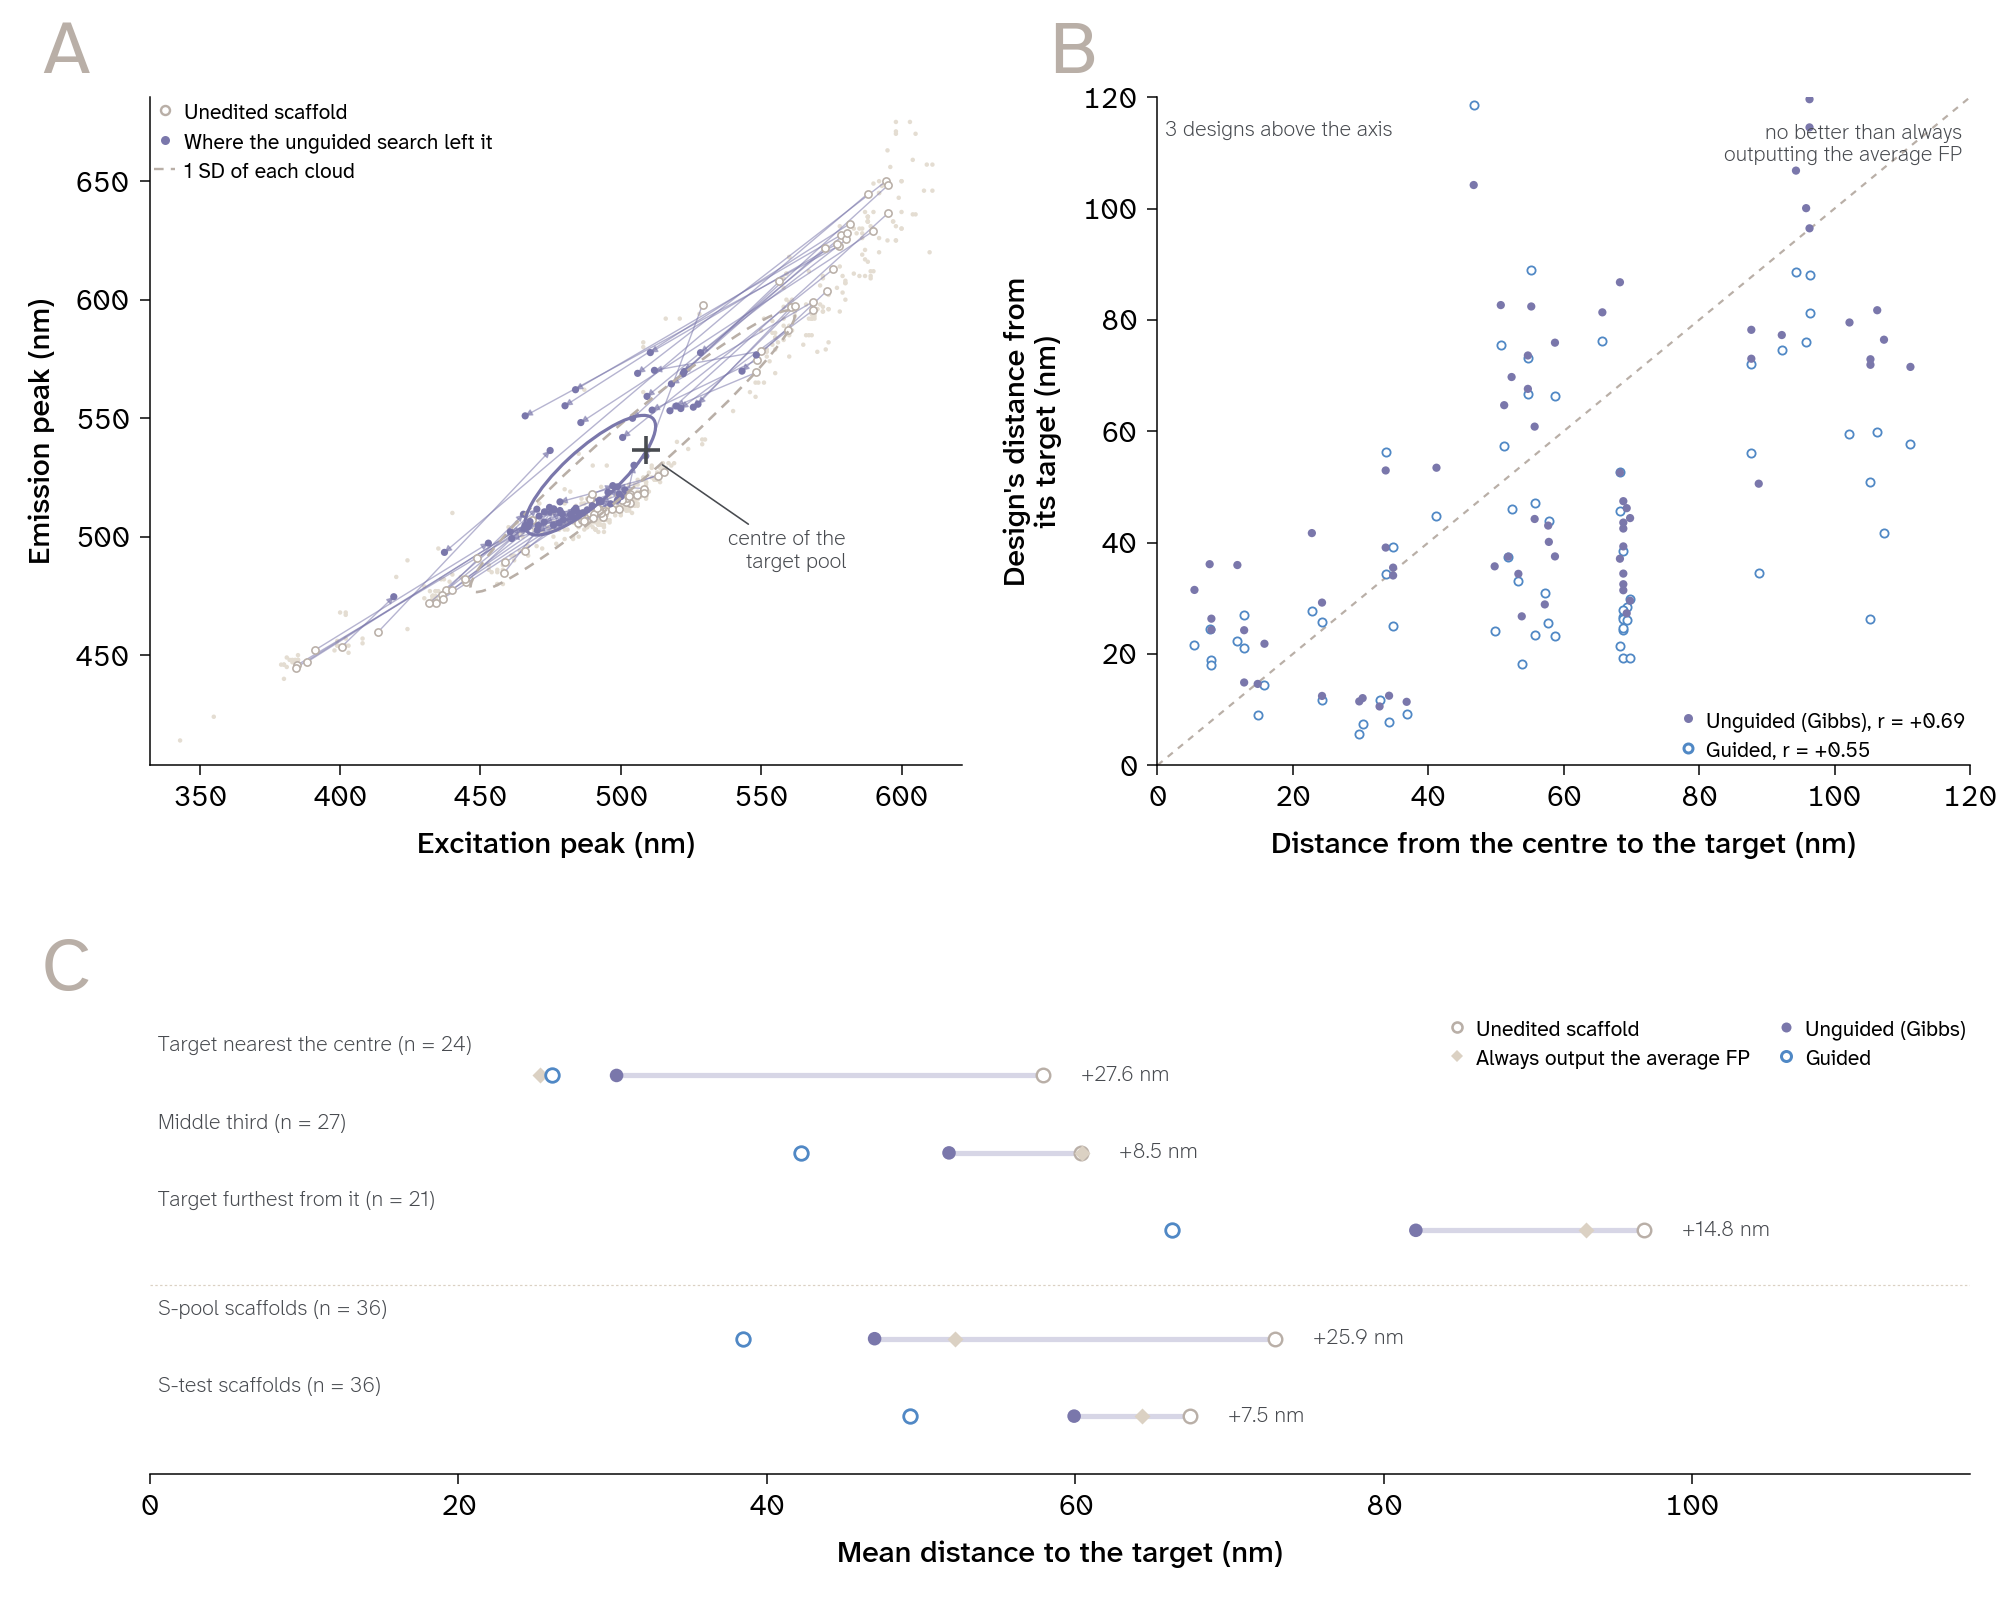

In [30]:
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

# Three panels, one per step of the argument: (A) the unguided search collapses onto the middle of
# the FP distribution whatever task it was given, (B) so its error is mostly just how far the target
# sits from that middle -- the score of a predictor that ignores the task -- and (C) so its apparent
# improvement over the scaffold swings wildly between groupings of the same 72 tasks without
# anything about the search changing.



def sd_ellipse(ax, x, y, color, **kw):
    """The 1-SD ellipse of a cloud. Drawn rather than left to the eye because excitation and
    emission are correlated enough that both clouds lie along the same diagonal, which hides a
    two-and-a-half-fold difference in spread."""
    vals, vecs = np.linalg.eigh(np.cov(x, y))
    order = vals.argsort()[::-1]
    w, h = 2 * np.sqrt(vals[order])
    ax.add_patch(Ellipse((x.mean(), y.mean()), w, h,
                         angle=np.degrees(np.arctan2(*vecs[:, order[0]][::-1])),
                         facecolor="none", edgecolor=color, **kw))


fig, axd = plt.subplot_mosaic("AB;CC", figsize=(FULL_WIDE * PX, 810 * PX), height_ratios=[1.45, 1])
fig.subplots_adjust(left=0.075, right=0.985, top=0.94, bottom=0.09, hspace=0.44, wspace=0.24)
for _letter in "ABC":
    apc.mpl.style_plot(axd[_letter], monospaced_axes="both")
    for _side in ("top", "right"):
        axd[_letter].spines[_side].set_visible(False)
    panel_letter(axd[_letter], _letter, dx=-54, dy=6)

# (A) where an unedited scaffold starts, and where resampling its pocket leaves it
ax = axd["A"]
ax.scatter(POOL[:, 0], POOL[:, 1], s=5, color=tint(NEUTRAL_SOFT, 0.75), edgecolor="none", zorder=1)
for _, r in land.iterrows():
    ax.annotate("", xy=(r.ux, r.uy), xytext=(r.sx, r.sy),
                arrowprops=dict(arrowstyle="-|>", color=CONTROL, lw=0.7, alpha=0.55,
                                shrinkA=0, shrinkB=0, mutation_scale=7), zorder=2)
ax.scatter(land.sx, land.sy, s=13, facecolor="white", edgecolor=NEUTRAL, linewidth=0.8, zorder=3)
ax.scatter(land.ux, land.uy, s=13, color=CONTROL, edgecolor="none", zorder=4)
sd_ellipse(ax, land.sx, land.sy, NEUTRAL, lw=1.3, ls=(0, (4, 3)), zorder=6)
sd_ellipse(ax, land.ux, land.uy, CONTROL, lw=1.6, zorder=6)
ax.scatter([CX], [CY], marker="+", s=190, color=str(apc.charcoal), linewidth=1.8, zorder=7)
ax.annotate("centre of the\ntarget pool", xy=(CX + 3, CY - 4), xytext=(96, -46),
            textcoords="offset points", ha="right", va="center",
            arrowprops=dict(arrowstyle="-", color=str(apc.charcoal), lw=0.8, shrinkA=2, shrinkB=4),
            **ANNOT)
ax.set_xlabel("Excitation peak (nm)")
ax.set_ylabel("Emission peak (nm)")
key(ax, [Line2D([], [], ls="none", marker="o", markersize=4.5, markerfacecolor="white",
                markeredgecolor=NEUTRAL, markeredgewidth=1.2, label="Unedited scaffold"),
         Line2D([], [], ls="none", marker="o", markersize=4.5, color=CONTROL,
                label="Where the unguided search left it"),
         Line2D([], [], color=NEUTRAL, lw=1.2, ls=(0, (4, 3)), label="1 SD of each cloud")],
    loc="upper left")

# (B) both arms against the predictor that ignores the task
ax = axd["B"]
HI = 120
_out = int(((land.u_err > HI) | (land.g_err > HI)).sum())
ax.plot((0, HI), (0, HI), ls=(0, (3, 3)), color=NEUTRAL, lw=1.1, zorder=1)
ax.scatter(land.base_err, land.g_err, s=17, facecolor="white", edgecolor=HIGHLIGHT, linewidth=0.9,
           zorder=2)
ax.scatter(land.base_err, land.u_err, s=17, color=CONTROL, edgecolor="none", zorder=3)
ax.set_xlim(0, HI)
ax.set_ylim(0, HI)
ax.set_xlabel("Distance from the centre to the target (nm)")
ax.set_ylabel("Design's distance from\nits target (nm)")
ax.annotate("no better than always\noutputting the average FP", xy=(HI, HI), xytext=(-4, -34),
            textcoords="offset points", ha="right", va="bottom", **ANNOT)
ax.annotate(f"{_out} designs above the axis", xy=(0.5, HI), xytext=(2, -12),
            textcoords="offset points", ha="left", va="top", **ANNOT)
key(ax, [Line2D([], [], ls="none", marker="o", markersize=4.5, color=CONTROL,
                label=f"Unguided (Gibbs), r = {np.corrcoef(land.base_err, land.u_err)[0, 1]:+.2f}"),
         Line2D([], [], ls="none", marker="o", markersize=4.5, markerfacecolor="white",
                markeredgecolor=HIGHLIGHT, markeredgewidth=1.5,
                label=f"Guided, r = {np.corrcoef(land.base_err, land.g_err)[0, 1]:+.2f}")],
    loc="lower right")

# (C) the apparent improvement over the scaffold, under two different groupings of the same 72 tasks
ax = axd["C"]
for y, (lab, x) in zip([4.3, 3.3, 2.3, 0.9, -0.1], ROWS):
    ax.plot([x.s_err.mean(), x.u_err.mean()], [y, y], color=tint(CONTROL, 0.3), lw=2.6, zorder=2,
            solid_capstyle="round")
    ax.scatter([x.base_err.mean()], [y], marker="D", s=32, color=NEUTRAL_SOFT, zorder=5)
    ax.scatter([x.s_err.mean()], [y], s=46, facecolor="white", edgecolor=NEUTRAL, lw=1.2, zorder=4)
    ax.scatter([x.u_err.mean()], [y], s=46, color=CONTROL, edgecolor="none", zorder=6)
    ax.scatter([x.g_err.mean()], [y], s=46, facecolor="white", edgecolor=HIGHLIGHT, lw=1.4, zorder=6)
    ax.text(0.5, y + 0.26, lab, ha="left", va="bottom", **ANNOT)
    ax.text(max(x.s_err.mean(), x.u_err.mean()) + 2.5, y, f"{x.u_gain.mean():+.1f} nm",
            ha="left", va="center", **ANNOT)
# The two groupings partition the same 72 tasks in different ways, so they are ruled apart rather
# than stacked as if they were five independent groups.
ax.axhline(1.6, color=NEUTRAL_SOFT, lw=0.6, ls=(0, (2, 2)), zorder=1)
ax.set_ylim(-0.85, 5.1)
ax.set_xlim(0, 118)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_xlabel("Mean distance to the target (nm)")
key(ax, [Line2D([], [], ls="none", marker="o", markersize=5, markerfacecolor="white",
                markeredgecolor=NEUTRAL, markeredgewidth=1.3, label="Unedited scaffold"),
         Line2D([], [], ls="none", marker="D", markersize=4.5, color=NEUTRAL_SOFT,
                label="Always output the average FP"),
         Line2D([], [], ls="none", marker="o", markersize=5, color=CONTROL, label="Unguided (Gibbs)"),
         Line2D([], [], ls="none", marker="o", markersize=5, markerfacecolor="white",
                markeredgecolor=HIGHLIGHT, markeredgewidth=1.5, label="Guided")],
    loc="upper right", ncol=2, columnspacing=1.2)

fig.savefig(f"{FIGDIR}/design_task2_null_regression_to_the_mean.svg")
fig.savefig(f"{FIGDIR}/design_task2_null_regression_to_the_mean.png", dpi=200)
plt.show()

**Figure 5. The unguided control does not improve on its scaffold by moving toward the target; it
improves by collapsing onto the middle of the fluorescent-protein distribution, which is a better
guess than a peripheral scaffold for a target drawn at random.** **(A)** Every task's unedited
scaffold (open) and where the unguided search left it (aster), joined by an arrow, over the 500
eligible targets in grey and the centre of that pool marked; ellipses are 1 SD of each cloud.
**(B)** Each arm's distance from its target against the distance from the pool centre to that target
— which is exactly the error of a predictor that ignores the scaffold, the target and the sequence
and always outputs the average FP. The dashed line is that predictor; below it is better than
knowing nothing. **(C)** The control's apparent improvement over the scaffold, under two different
groupings of the same 72 tasks: by how peripheral the target is (top three, ruled off) and by cohort
(bottom two). Both arms are taken at the final cycle and averaged over their trials, as in Figure 1.

**The collapse is the whole mechanism.** Scaffolds are spread 58 nm (excitation) and 59 (emission)
about their mean and sit 70.4 nm from the pool centre; the designs the unguided search returns are
spread **23 and 25 nm** and sit **37.3 nm** from it. Resampling a pocket does not preserve what made
a scaffold unusual. The targets, meanwhile, are spread 66 and 62 nm and average 83.5 nm from the
centre, so moving inward closes distance on most of them for free.

**Against a predictor that cannot be designing, the control barely registers.** Always outputting the
average FP scores **58.2 nm**; the unguided arm scores 53.4 and beats that predictor on only 40 of 72
tasks. Its error tracks it at *r* = **+0.69** — the control's result is largely a restatement of where
each target happens to sit. The unedited scaffold, by contrast, correlates +0.36, because a scaffold
is somewhere specific rather than in the middle. **This is the number that makes the guided arm's
case**: 43.9 nm, beating the same predictor on 48 of 72 tasks, and 14.3 nm better than it on the
mean.

**So "improvement over the scaffold" is not a property of the search.** It is the gap between two
things that were fixed before any design ran — how far the scaffold started from the target, and how
peripheral the target is — and it correlates with that difference at *r* = **+0.83**. Slice the same
72 tasks by target periphery and the control's gain reads +27.6, +8.5 and +14.8 nm; slice them by
cohort and it reads +25.9 and +7.5. Nothing about the arm changed between those two readings. Note
the tertiles are not monotone: the furthest third also starts furthest away, so both terms move at
once, and target periphery on its own correlates with the gain at only −0.19.

**Figure 1's held-out result was mostly the control.** Going from S-pool to S-test, the average-FP
error rises 12.1 nm and the control's error rises 12.9 — the same number — while the scaffolds
actually start 5.5 nm *closer* to their targets. The control looks strong on S-pool (worse than its
scaffold on 2/36) and weak on S-test (16/36) because S-test targets sit further out, not because
those scaffolds were held out. The guided arm's own S-pool-to-S-test penalty is 10.8 nm, slightly
*less* than the shift in the tasks themselves.

**One caveat this figure cannot settle.** Part of the inward pull may be the oracle regressing
mutated, less confidently-typed sequences toward its own training mean rather than real
photophysics. Both stories produce exactly this signature, and both carry the same lesson: the
unedited scaffold is the wrong reference for judging a design run, and the average-FP predictor is
the right one.